# Monte Carlo algorithm

*  Generate random densities $f_1,\dots,f_{n+1}$
* For each $t=1,\dots,n+1$:

* * simulate a process $(Z_{it}: i=1,\dots,n_t)$ with marginal density $f_t$ (possibly iid draws from $f_t$ for simplicity)
* * obtain the kernel density estimator $\hat{f}_t$ using the data $(Z_{it}: i=1,\dots,n_t)$
* * Define $Y_t = \Lambda(\hat{f}_t)$

* Apply the method of Bathia et al. (2010) to the sample $Y_1,\dots,Y_n$
* Obtain a forecast $\hat{Y}_{n+1}$
* Compare:
* * $\hat{Y}_{n+1}$ with $Y_{n+1}$
* * $\hat{Y}_{n+1}$ with $\Lambda(f_{n+1})$
* * $\hat{Y}_{n+1}$ with $X_{n+1}^{\text{boot}}$ (see definition below)
* * $\Lambda^{-1}(\hat{Y}_{n+1})$ with $\hat{f}_{n+1}$
* * $\Lambda^{-1}(\hat{Y}_{n+1})$ with ${f}_{n+1}$
* * $\Lambda^{-1}(\hat{Y}_{n+1})$ with $\Lambda^{-1}(X_{n+1}^{\text{boot}})$

To obtain $X_{t}^{\text{boot}}$:

* given $f_{t}$, for $b=1,\dots,B$,
* *    simulate a process $(Z_{it}^{(b)}: i=1,\dots,n_t)$ with marginal density $f_t$
* *    obtain the kernel density estimator $\hat{f}_t^{(b)}$ using the data $(Z_{it}^{(b)}: i=1,\dots,n_t)$
* *    define $Y_t^{(b)} = \Lambda(\hat{f}_t^{(b)})$
* * Define $X_t^{\text{boot}} = \frac1B \sum_{b=1}^B Y_{t}^{(b)}$


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid
import pmdarima as pm
import matplotlib.pyplot as plt

import os
import logging
from pathlib import Path
from datetime import datetime
import joblib
from tqdm.auto import tqdm

import sys
sys.path.append('../../')
import src.fda.utils                    as fdaUtils
import src.forecasting.pipelines        as fp
import src.forecasting.accuracy         as acc
import src.forecasting.simulations      as sim
import src.forecasting.cross_validation as crossVal
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt
import src.fda.dfpc                     as dfpc

In [2]:
EXECUTION_DATE : str = datetime.now().strftime('%Y%m%d')
LOG_PATH       : str = f'../../logs/simulations/{EXECUTION_DATE}.log'
FILES_PATH     : str = f'../../data/interim/simulation/{EXECUTION_DATE}/'
DATABASES_PATH : str = f'../../data/interim/simulation/{EXECUTION_DATE}/databases/'
SIM_LQD_PATH       : str = f'../../data/interim/simulation/{EXECUTION_DATE}/sim_lqds/'
KDE_LQD_PATH   : str = f'../../data/interim/simulation/{EXECUTION_DATE}/kde_lqds/'
ALL_KDES_PATH  : str = f'../../data/interim/simulation/{EXECUTION_DATE}/all_kdes.jbl'
CV_FILES_PATH  : str = f'../../data/interim/simulation/{EXECUTION_DATE}/progress/'
CV_FC_PATH     : str = f'../../data/interim/simulation/{EXECUTION_DATE}/cv/'


Path(FILES_PATH).mkdir(parents=True, exist_ok=True)
Path(DATABASES_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FILES_PATH).mkdir(parents=True, exist_ok=True)
Path(SIM_LQD_PATH).mkdir(parents=True, exist_ok=True)
Path(KDE_LQD_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FC_PATH).mkdir(parents=True, exist_ok=True)

# Simulations

In [3]:
# simulation objects
N_CURVES  = 300
N_REPS    = 100
N_RETURNS = 288 # (60/5)*12
m = 5001
x = np.linspace(-10, 10, m)
u = np.linspace(0, 1, m)

# base densities
pdf_normal = sim.generate_base_density(
                                       grid=x, 
                                       kind='gaussian',
                                       sigma=2, 
                                       mu=0
                                       )
pdf_t      = sim.generate_base_density(
                                       grid=x, 
                                       kind='student_t', 
                                       df=4, 
                                       scale=np.sqrt(2)
                                       )
base_densities = {
    "normal": pdf_normal,
    "t": pdf_t
}

# parameters
param_grid = {
    'base_pdf_name': list(base_densities.keys()),
    'basis': ['sine'],
    'dimensions': [2, 3, 4],
    'noise_type': ['Null'],
    'error_sigma': [0.25],
}

scenarios = list(ParameterGrid(param_grid))

scenarios = []
for i, params in enumerate(ParameterGrid(param_grid)):
    params['scenario_id'] = i
    scenarios.append(params)

dim_scenarios = pd.DataFrame({"scenario": [x["scenario_id"] for x in scenarios], "scenario_description": [f"{x.values()}" for x in scenarios]})

In [4]:
for scenario in scenarios:
    print(scenario)

{'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 2, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 0}
{'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 3, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 1}
{'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 4, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 2}
{'base_pdf_name': 't', 'basis': 'sine', 'dimensions': 2, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 3}
{'base_pdf_name': 't', 'basis': 'sine', 'dimensions': 3, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 4}
{'base_pdf_name': 't', 'basis': 'sine', 'dimensions': 4, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 5}


In [4]:
# SIMULATE DATABASES
simulations_database = {}

n_scenarios = len(scenarios)

for scen_count, scenario in enumerate(scenarios, start=1):
    print(scenario)

    scenario_id = scenario["scenario_id"]
    pdf = base_densities[scenario['base_pdf_name']]

    simulations_database[scenario_id] = {
        "params": scenario.copy(),
        "replications": {}   # <-- FIX: now indexed by n_rep
    }

    for n_rep in range(N_REPS):
        print(f"\t{n_rep+1}/{N_REPS}")

        sim_engine = sim.FDFSimulator(u_grid=u, x_grid=x)

        sim_engine.run_simulation( 
            n_curves    = N_CURVES, 
            base_pdf    = pdf,
            basis       = scenario["basis"],   
            dimensions  = scenario["dimensions"],
            noise_type  = scenario["noise_type"],
            error_sigma = scenario["error_sigma"]
        )

        simulations_database[scenario_id]["replications"][n_rep] = {
            "densities": sim_engine.result["densities"],
            "samples":   sim_engine.get_samples_df(n_samples=N_RETURNS)
        }

    print(f"{scen_count}/{n_scenarios}")

{'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 2, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 0}
	1/100
	2/100
	3/100
	4/100
	5/100
	6/100
	7/100
	8/100
	9/100
	10/100
	11/100
	12/100
	13/100
	14/100
	15/100
	16/100
	17/100
	18/100
	19/100
	20/100
	21/100
	22/100
	23/100
	24/100
	25/100
	26/100
	27/100
	28/100
	29/100
	30/100
	31/100
	32/100
	33/100
	34/100
	35/100
	36/100
	37/100
	38/100
	39/100
	40/100
	41/100
	42/100
	43/100
	44/100
	45/100
	46/100
	47/100
	48/100
	49/100
	50/100
	51/100
	52/100
	53/100
	54/100
	55/100
	56/100
	57/100
	58/100
	59/100
	60/100
	61/100
	62/100
	63/100
	64/100
	65/100
	66/100
	67/100
	68/100
	69/100
	70/100
	71/100
	72/100
	73/100
	74/100
	75/100
	76/100
	77/100
	78/100
	79/100
	80/100
	81/100
	82/100
	83/100
	84/100
	85/100
	86/100
	87/100
	88/100
	89/100
	90/100
	91/100
	92/100
	93/100
	94/100
	95/100
	96/100
	97/100
	98/100
	99/100
	100/100
1/6
{'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 3, 'error_sigma': 0.25

In [5]:
# joblib.dump(simulations_database, f"{FILES_PATH}simulation_database.jbl")

simulations_database = joblib.load(f"../data/interim/simulation/20260421/simulation_database.jbl")
# simulations_database = joblib.load(f"{FILES_PATH}simulation_database.jbl")

# KDE

In [6]:
# KDE params
# t_dfs = range(3,6)
t_dfs = [3]

rot_grid = {
    "method": ["rot"],
    "kernel": ["gaussian"],
    "sigma_robust": [False]
}

rot_grid_t = {
    "method": ["rot"],
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
    "sigma_robust": [False]
}

adaptive_grid = {
    "method": ["adaptive"], 
    "kernel": ["gaussian"]
}

adaptive_grid_t = {
    "method": ["adaptive"], 
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
}


density_param_grid = {}
for grid in [rot_grid, rot_grid_t, adaptive_grid, adaptive_grid_t]:
    for params in ParameterGrid(grid):
        
        key_parts = [params["kernel"]]
        if "method" in params: key_parts.append(params["method"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        full_model_name = "_".join(key_parts).replace(".", "")
        
        kernel_label = params["kernel"]
        if "df" in params:
            kernel_label += f"+df={params['df']}"
            
        bw_label = params.get("method", "fixed")
        if params.get("sigma_robust"): bw_label += "_robust"
        if params.get("cv") == "LOO": bw_label += "_loo"


        density_param_grid[full_model_name] = {
            "kernel": kernel_label,
            "bandwidth": bw_label,
            "params": params  
        }

print("KDE models:")
for name, values in density_param_grid.items():
    print("\t",name, ":", values["params"])

print(f"Total KDE models: {len(density_param_grid.items())}")

KDE models:
	 gaussian_rot : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': False}
	 t-student_rot_df=3 : {'df': 3, 'kernel': 't-student', 'method': 'rot', 'sigma_robust': False}
	 gaussian_adaptive : {'kernel': 'gaussian', 'method': 'adaptive'}
	 t-student_adaptive_df=3 : {'df': 3, 'kernel': 't-student', 'method': 'adaptive'}
Total KDE models: 4


In [ ]:
# Estimation
total_models = len(density_param_grid) * N_REPS * len(scenarios)
pbar = tqdm(total=total_models, desc="Total CV Progress")

kde_databases = {}
for scenario, database in simulations_database.items():
    print(f"Processing configuration for {database['params']}")
    kde_databases[scenario] = {}
    sim_reps_database = simulations_database[scenario]["replications"]
    
    for n_rep, df in sim_reps_database.items():
        print(f"\t{n_rep}")
        returns_df = sim_reps_database[n_rep]['samples']
        kde_databases[scenario][n_rep] = {}
        
        for kde_bw_name, kde_bw_params in density_param_grid.items():
            print(f"\t simulation n. = {n_rep}: {kde_bw_name}")
            
            # bandwidths
            df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params["params"])    
            kde_params = {k: v for k, v in kde_bw_params["params"].items() if k in ['kernel', 'df']}
            
            # kdes
            df_grids, df_densities = kde.df_to_kde(
                X=returns_df, 
                h=df_h, 
                normalize_densities=False,
                **kde_params
            )

            rep_result = {
                        "scenario":     scenario,
                        "n_rep":        n_rep,
                        "model_name":   kde_bw_name,
                        "kde_params":   kde_bw_params["kernel"],
                        "kernel":       kde_bw_params["params"]["kernel"],
                        "bw_params":    kde_bw_params["bandwidth"],
                        "bw_method":    kde_bw_params["params"]["method"],
                        "df_h":         df_h,
                        "df_support":   df_grids,
                        "df_densities": df_densities
                }

            # kde_databases[scenario][n_rep][kde_bw_name] = rep_result
            
            joblib.dump(rep_result, f"{CV_FILES_PATH}scenario_{scenario}_rep_{n_rep}_kde_{kde_bw_name}.jbl")

            pbar.update(1)

            del df_h
            del df_grids
            del df_densities
            del kde_params


Total CV Progress:   0%|          | 0/2400 [00:00<?, ?it/s]

Processing configuration for {'base_pdf_name': 'normal', 'basis': 'sine', 'dimensions': 2, 'error_sigma': 0.25, 'noise_type': 'Null', 'scenario_id': 0}
	0
	 simulation n. = 0: gaussian_rot
	 simulation n. = 0: t-student_rot_df=3
	 simulation n. = 0: gaussian_adaptive
	 simulation n. = 0: t-student_adaptive_df=3
	1
	 simulation n. = 1: gaussian_rot
	 simulation n. = 1: t-student_rot_df=3
	 simulation n. = 1: gaussian_adaptive
	 simulation n. = 1: t-student_adaptive_df=3
	2
	 simulation n. = 2: gaussian_rot
	 simulation n. = 2: t-student_rot_df=3
	 simulation n. = 2: gaussian_adaptive
	 simulation n. = 2: t-student_adaptive_df=3
	3
	 simulation n. = 3: gaussian_rot
	 simulation n. = 3: t-student_rot_df=3
	 simulation n. = 3: gaussian_adaptive
	 simulation n. = 3: t-student_adaptive_df=3
	4
	 simulation n. = 4: gaussian_rot
	 simulation n. = 4: t-student_rot_df=3
	 simulation n. = 4: gaussian_adaptive
	 simulation n. = 4: t-student_adaptive_df=3
	5
	 simulation n. = 5: gaussian_rot
	 simu

In [ ]:
# kdes_paths = [''.join([CV_FILES_PATH, x]) for x in os.listdir(CV_FILES_PATH) if "scenario" in x]
kde_jbls_path = '../../data/interim/simulation/20260421/progress/'
kdes_paths = [''.join([kde_jbls_path, x]) for x in os.listdir(kde_jbls_path) if "scenario" in x]

kde_addresses = []
for path_name in kdes_paths:
    obj = joblib.load(path_name)
    kde_address = {
        "scenario":   obj["scenario"],
        "n_rep":      obj["n_rep"],
        "model_name": obj["model_name"],
        "address":    path_name
    }
    kde_addresses.append(kde_address)

kde_addresses = sorted(
    kde_addresses,
    key=lambda x: (x["scenario"], x["n_rep"], x["model_name"])
)

kde_index = {
    (d["scenario"], d["n_rep"], d["model_name"]): d["address"]
    for d in kde_addresses
}

# $Y_t=\Lambda(\hat{f_t})$

In [ ]:
KdFPC_kwargs = {
    "p": 5,
    "select_ncomp": "variance"
}

In [ ]:
n_kde_addresses = len(kde_addresses)
count = 0
for kde in kde_addresses:
    scenario_kde_dict = joblib.load(kde["address"])
    id_scenario_kde     = scenario_kde_dict["scenario"]
    n_rep               = scenario_kde_dict["n_rep"]
    model_name_path     = scenario_kde_dict['model_name']
    model_name          = scenario_kde_dict['model_name'].replace("_", " ")
    # carregar KDE
    # transformar para L2
    # salvar

    mlqdt = lqdt.mLQDT()
    model_lqd = mlqdt.transform(
        densities=scenario_kde_dict["df_densities"],
        densities_supports=scenario_kde_dict["df_support"], 
        verbose=False
        )
    # self.model_lqd.densities_to_lqdensities(verbose=False)
    
    # 2. L2 Expansion (K_dFPC)
    lqd_values  = model_lqd.lqd.values
    lqd_support = model_lqd.lqd_support
    
    KdFPC_kwargs.update({
        "u": lqd_support,
        "du": model_lqd.du
    })
    
    model_kdfpc = dfpc.K_dFPC(lqd_values)
    model_kdfpc.fit(**KdFPC_kwargs)

    Y_t = pd.DataFrame(model_kdfpc.Y)
    Y_t.columns = df_densities.columns
    Y_t.index   = model_lqd.lqd_support

    kde_mlqdt_result = {
                "scenario":     kde["scenario"],
                "n_rep":        kde["n_rep"],
                "model_name":   kde["model_name"],
                "kde_mlqdt":    Y_t
        }
    
    joblib.dump(kde_mlqdt_result, f"{KDE_LQD_PATH}lqd___scenario_{id_scenario_kde}___rep_{n_rep}___kde_{model_name_path}.jbl")

    count += 1
    print(f"{count}/{n_kde_addresses}")

1/2400
2/2400
3/2400
4/2400
5/2400
6/2400
7/2400
8/2400
9/2400
10/2400
11/2400
12/2400
13/2400
14/2400
15/2400
16/2400
17/2400
18/2400
19/2400
20/2400
21/2400
22/2400
23/2400
24/2400
25/2400
26/2400
27/2400
28/2400
29/2400
30/2400
31/2400
32/2400
33/2400
34/2400
35/2400
36/2400
37/2400
38/2400
39/2400
40/2400
41/2400
42/2400
43/2400
44/2400
45/2400
46/2400
47/2400
48/2400
49/2400
50/2400
51/2400
52/2400
53/2400
54/2400
55/2400
56/2400
57/2400
58/2400
59/2400
60/2400
61/2400
62/2400
63/2400
64/2400
65/2400
66/2400
67/2400
68/2400
69/2400
70/2400
71/2400
72/2400
73/2400
74/2400
75/2400
76/2400
77/2400
78/2400
79/2400
80/2400
81/2400
82/2400
83/2400
84/2400
85/2400
86/2400
87/2400
88/2400
89/2400
90/2400
91/2400
92/2400
93/2400
94/2400
95/2400
96/2400
97/2400
98/2400
99/2400
100/2400
101/2400
102/2400
103/2400
104/2400
105/2400
106/2400
107/2400
108/2400
109/2400
110/2400
111/2400
112/2400
113/2400
114/2400
115/2400
116/2400
117/2400
118/2400
119/2400
120/2400
121/2400
122/2400
123/2400
1

In [ ]:
# kdes_lqd_paths = [''.join([KDE_LQD_PATH, x]) for x in os.listdir(KDE_LQD_PATH) if "scenario" in x]
lqd_jbls_path = '../../data/interim/simulation/20260421/kde_lqds/'
kdes_lqd_paths = [''.join([lqd_jbls_path, x]) for x in os.listdir(lqd_jbls_path) if "scenario" in x]


kdes_lqd_addresses = []
for path_name in kdes_lqd_paths:
    obj = joblib.load(path_name)
    kde_address = {
        "scenario":   obj["scenario"],
        "n_rep":      obj["n_rep"],
        "model_name": obj["model_name"],
        "address":    path_name
    }
    kdes_lqd_addresses.append(kde_address)

kde_lqd_index = {
    (d["scenario"], d["n_rep"], d["model_name"]): d["address"]
    for d in kdes_lqd_addresses
}

* simulate a process $(Z_{it}: i=1,\dots,n_t)$ with marginal density $f_t$ (possibly iid draws from $f_t$ for simplicity)
* obtain the kernel density estimator $\hat{f}_t$ using the data $(Z_{it}: i=1,\dots,n_t)$
* Define $Y_t = \Lambda(\hat{f}_t)$
* Obtain a forecast $\hat{Y}_{n+1}$
* Compare:
* * $\hat{Y}_{n+1}$ with $Y_{n+1}$
* * $\hat{Y}_{n+1}$ with $\Lambda(f_{n+1})$
* * $\hat{Y}_{n+1}$ with $X_{n+1}^{\text{boot}}$ (see definition below)
* * $\Lambda^{-1}(\hat{Y}_{n+1})$ with $\hat{f}_{n+1}$
* * $\Lambda^{-1}(\hat{Y}_{n+1})$ with ${f}_{n+1}$
* * $\Lambda^{-1}(\hat{Y}_{n+1})$ with $\Lambda^{-1}(X_{n+1}^{\text{boot}})$

# Cross-validation

In [ ]:
# 1. Setup Logger
logger = logging.getLogger("Density_Estimation")
logger.setLevel(logging.DEBUG)

# 2. Setup File Handler
file_handler = logging.FileHandler(LOG_PATH)
file_handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(file_handler)

# 3. CAPTURE WARNINGS: This handles "Forecast with mean" style warnings
logging.captureWarnings(True)

In [ ]:
initial_window = 200
horizon=1

total_models = len(kde_addresses)
pbar = tqdm(total=total_models, desc="Total CV Progress")
logger.info("\nInitiating cross validation...")
for kde_address in kde_addresses:
    scenario_kde_dict = joblib.load(kde_address["address"])

    # KDE database
    id_scenario_kde     = scenario_kde_dict["scenario"]
    sim_info            = simulations_database[id_scenario_kde]["params"]
    n_rep               = scenario_kde_dict["n_rep"]
    model_name_path     = scenario_kde_dict['model_name']
    model_name          = scenario_kde_dict['model_name'].replace("_", " ")
    logger.info(
            f"Scenario: {id_scenario_kde} | n_rep: {n_rep} | KDE model: {model_name}"
            )
    df_support, df_densities = scenario_kde_dict["df_support"], scenario_kde_dict["df_densities"]

    # Simulations database
    sim_densities         = simulations_database[id_scenario_kde]["replications"][n_rep]["densities"]
    sim_densities_supp    = sim_densities.copy()
    sim_densities_supp.loc[:,:] = sim_densities_supp.index.to_numpy()[:, None]


    # L2 database
    kde_lqd_address       = kde_lqd_index.get((id_scenario_kde, n_rep, scenario_kde_dict['model_name']))
    scenario_kde_lqd      = joblib.load(kde_lqd_address)["kde_mlqdt"]
    scenario_kde_lqd_supp = scenario_kde_lqd.copy()
    scenario_kde_lqd_supp.loc[:,:] = scenario_kde_lqd_supp.index.to_numpy()[:, None]
    
    # Cross-validation
    windows = crossVal.expanding_window_cv(df_densities.shape[1], h=horizon, initial_window=initial_window)
#     curves_hist = []
    measures = []
    for fold, window in enumerate(windows):
            fold += 1
            print(f"\t\t>>> cv {fold}/{len(windows)}")
            idx_train      = window[0]
            idx_test       = window[1]
            test_date      = df_densities.columns[idx_test]
            
            #------------ target variables ------------#
            Y_t_support, Y_t                   = scenario_kde_lqd_supp.loc[:, test_date], scenario_kde_lqd.loc[:, test_date]
            # lambda(f_{n+1})
            # X_boot
            f_hat_t_supp, f_hat_t = df_support.loc[:, test_date], df_densities.loc[:, test_date]
            f_t_support,  f_t     = sim_densities_supp.loc[:, test_date], sim_densities.loc[:, test_date]
            # lambda^{-1}(X_boot)
            #-----------------------------------------#

            # Train-test split
            kde_train_support, kde_train = df_support.iloc[:,idx_train], df_densities.iloc[:,idx_train]
            
            # Forecasting
            forecaster = fp.DensityForecaster(kdfpc_kwargs=KdFPC_kwargs, maxlags=10)
            forecaster.fit(kde_train, kde_train_support)
            mdfpc_fc = forecaster.predict(horizon=1, var_lags=None, forecast_index=test_date)

            # Predictions
            Y_hat_t = mdfpc_fc["future_L2_curves"]

            lambda_inv_Y_hat_t_supp=  mdfpc_fc["future_supports"]
            lambda_inv_Y_hat_t =      mdfpc_fc["future_densities"]

            #------------ common grid ------------#
            # \hat{Y}_{n+1} x  Y_{n+1}
            acc_measures = acc.overall_measures(forecast=Y_hat_t, test=Y_t)
            temp_df = pd.DataFrame({
                    "support":  Y_t.index,
                    "actual":   Y_t.iloc[:, 0].values,
                    "forecast": Y_hat_t.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "yHatFc_Y",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \Lambda^{-1}(\hat{Y}_{n+1}) x  \hat{f}_{n+1}
            df_supp, df_kde, df_fc = fdaUtils.align_densities(
                                            f_hat_t_supp, 
                                            f_hat_t, 
                                            lambda_inv_Y_hat_t_supp, 
                                            lambda_inv_Y_hat_t, 
                                            lambda_inv_Y_hat_t.columns
                                            )
            acc_measures = acc.overall_measures(forecast=df_fc, test=df_kde)
            temp_df = pd.DataFrame({
                    "support":  df_support.iloc[:,0].values,
                    "actual":   df_kde.iloc[:, 0].values,
                    "forecast": df_fc.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "fHatFc_fHat",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \Lambda^{-1}(\hat{Y}_{n+1}) x  f_{n+1}
            df_supp, df_kde, df_fc = fdaUtils.align_densities(
                                            f_t_support, 
                                            f_t, 
                                            lambda_inv_Y_hat_t_supp, 
                                            lambda_inv_Y_hat_t, 
                                            lambda_inv_Y_hat_t.columns
                                            )
            acc_measures = acc.overall_measures(forecast=df_fc, test=df_kde)
            temp_df = pd.DataFrame({
                    "support":  df_support.iloc[:,0].values,
                    "actual":   df_kde.iloc[:, 0].values,
                    "forecast": df_fc.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold": fold,
                    "comparison": "fHatTp1Fc_f",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
    joblib.dump(measures, f"{CV_FC_PATH}cvFc___scenario_{id_scenario_kde}___rep_{n_rep}___kde_{model_name_path}.jbl")
    pbar.update(1)

Total CV Progress:   0%|          | 0/2400 [00:00<?, ?it/s]

		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2
		>>> cv 2/2
		>>> cv 1/2

KeyboardInterrupt: 

In [58]:
cv_results = []
cv_files = [''.join([CV_FC_PATH,x]) for x in os.listdir(CV_FC_PATH)]
for file in cv_files:
    cv_results.append(pd.DataFrame(joblib.load(file)))
df_cv_results = pd.concat(cv_results)
df_cv_results.sort_values(by=["scenario", "n_rep", "model_name"], inplace=True)

# Results

In [59]:
cv_results = []
cv_files = [''.join([CV_FC_PATH,x]) for x in os.listdir(CV_FC_PATH)]
for file in cv_files:
    cv_results.append(pd.DataFrame(joblib.load(file)))
df_cv_results = pd.concat(cv_results)
df_cv_results.sort_values(by=["scenario", "n_rep", "model_name"], inplace=True)

In [60]:
df_cv_results.head()

,scenario,n_rep,model_name,fold,comparison,fc_date,KLD,JSD,L_1,L_2,L_INFTY,curves
0,0,0,gaussian adaptive,1,yHatFc_Y,2026-04-20,0.011858,0.001482,723.208265,11.586177,0.516527,actual forecast fo...
1,0,0,gaussian adaptive,1,fHatFc_fHat,2026-04-20,0.099092,0.008732,68.333480,1.506980,0.057590,actual forecast ...
2,0,0,gaussian adaptive,1,fHatTp1Fc_f,2026-04-20,0.024586,0.000370,16.607187,0.298574,0.009661,actual forecast fo...
3,0,0,gaussian adaptive,2,yHatFc_Y,2026-04-21,0.000498,0.000062,148.165879,2.700176,0.133484,actual forecast fo...
4,0,0,gaussian adaptive,2,fHatFc_fHat,2026-04-21,0.009446,0.000572,18.606447,0.336493,0.010988,actual forecast ...


In [61]:
df_cv_results_desc = df_cv_results.merge(dim_scenarios, on="scenario")

In [62]:
df_cv_results_desc.groupby(["scenario", "comparison", "scenario_description", "model_name"], as_index=False)["L_1"].mean().sort_values(by="L_1")

,scenario,comparison,scenario_description,model_name,L_1
4,0,fHatTp1Fc_f,"dict_values(['normal', 'sine', 2, 0.25, 'Null'...",gaussian adaptive,29.611526
5,0,fHatTp1Fc_f,"dict_values(['normal', 'sine', 2, 0.25, 'Null'...",gaussian rot,30.535952
6,0,fHatTp1Fc_f,"dict_values(['normal', 'sine', 2, 0.25, 'Null'...",t-student adaptive df=3,32.594102
17,1,fHatTp1Fc_f,"dict_values(['normal', 'sine', 3, 0.25, 'Null'...",gaussian rot,32.796074
3,0,fHatFc_fHat,"dict_values(['normal', 'sine', 2, 0.25, 'Null'...",t-student rot df=3,33.929416
18,1,fHatTp1Fc_f,"dict_values(['normal', 'sine', 3, 0.25, 'Null'...",t-student adaptive df=3,34.739336
15,1,fHatFc_fHat,"dict_values(['normal', 'sine', 3, 0.25, 'Null'...",t-student rot df=3,35.274391
2,0,fHatFc_fHat,"dict_values(['normal', 'sine', 2, 0.25, 'Null'...",t-student adaptive df=3,37.162895
1,0,fHatFc_fHat,"dict_values(['normal', 'sine', 2, 0.25, 'Null'...",gaussian rot,38.306938
13,1,fHatFc_fHat,"dict_values(['normal', 'sine', 3, 0.25, 'Null'...",gaussian rot,39.075950


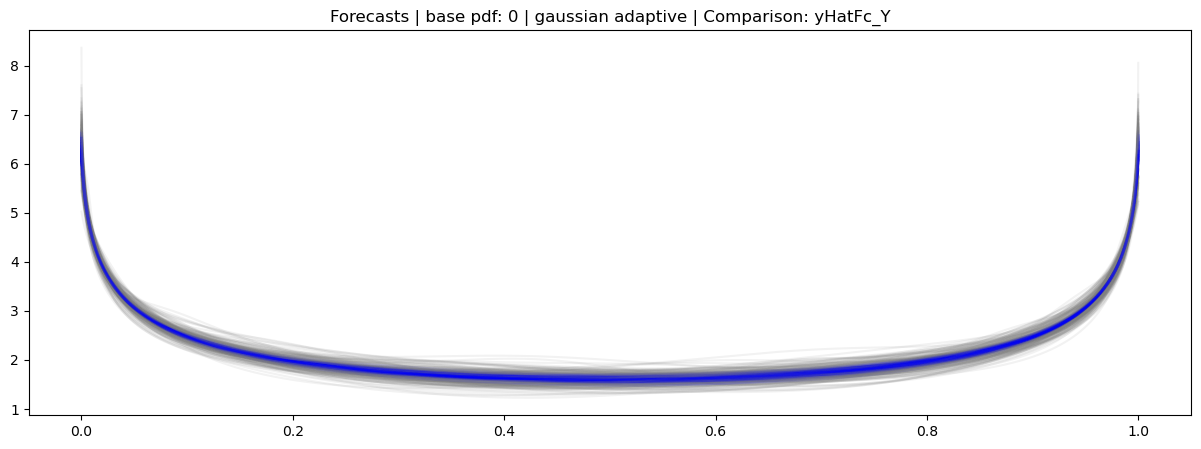

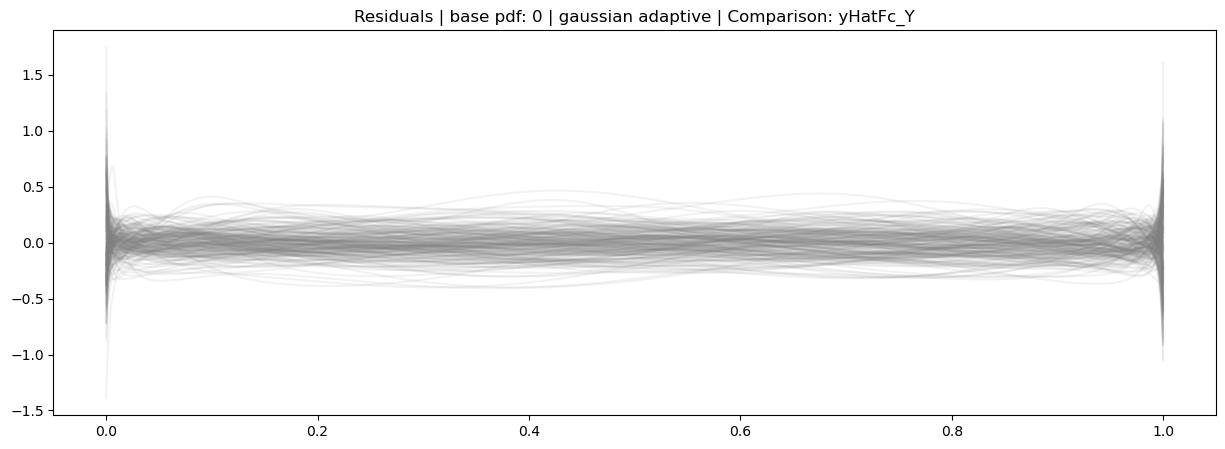

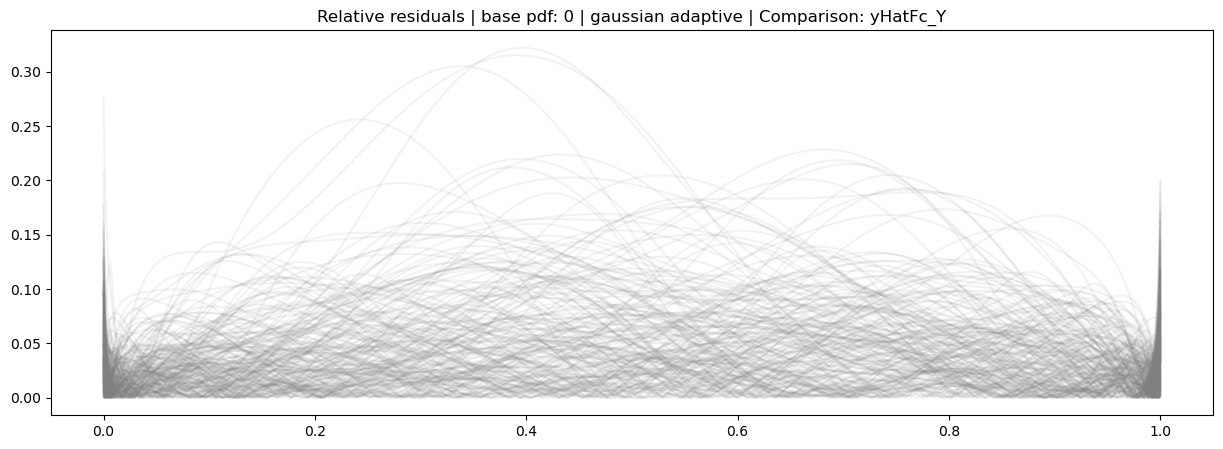

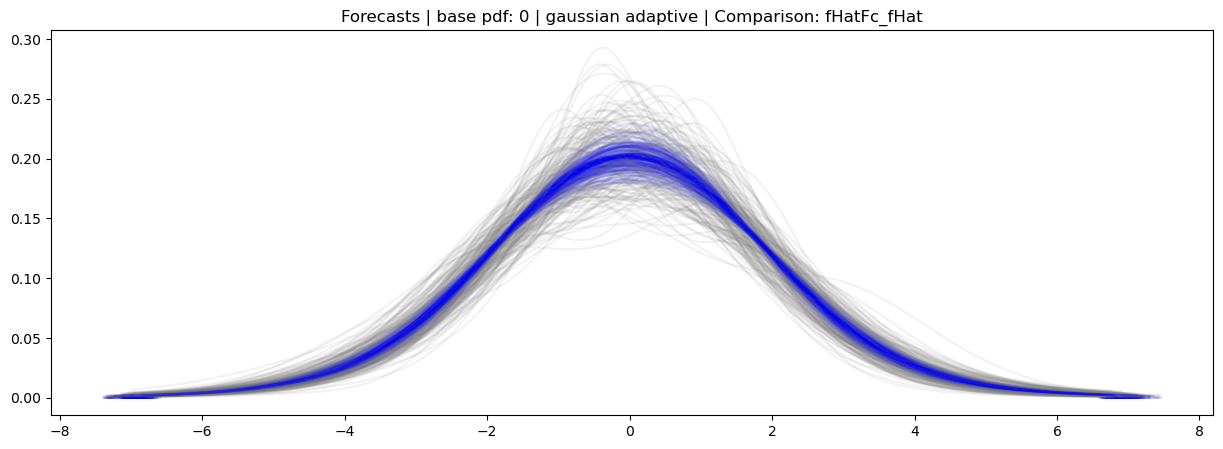

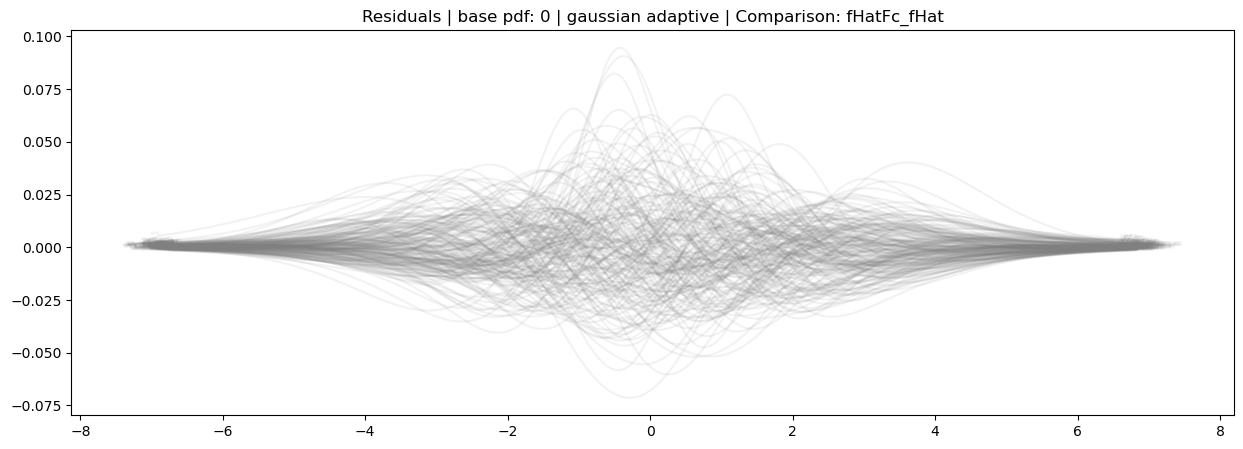

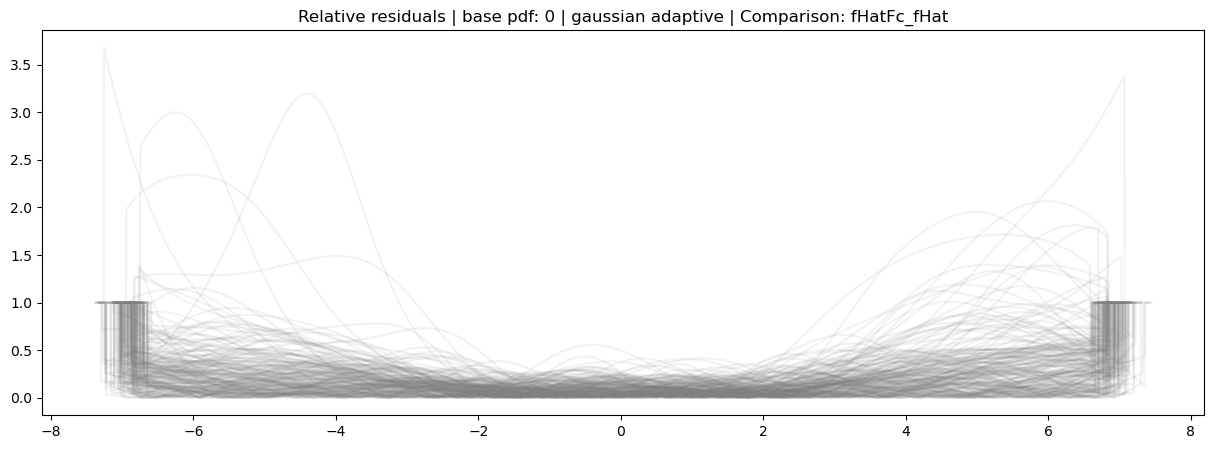

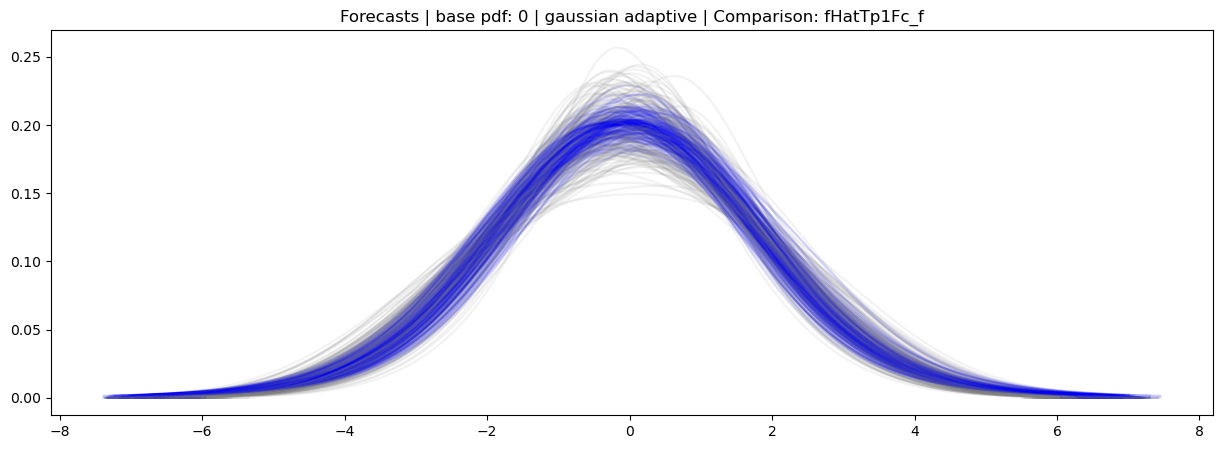

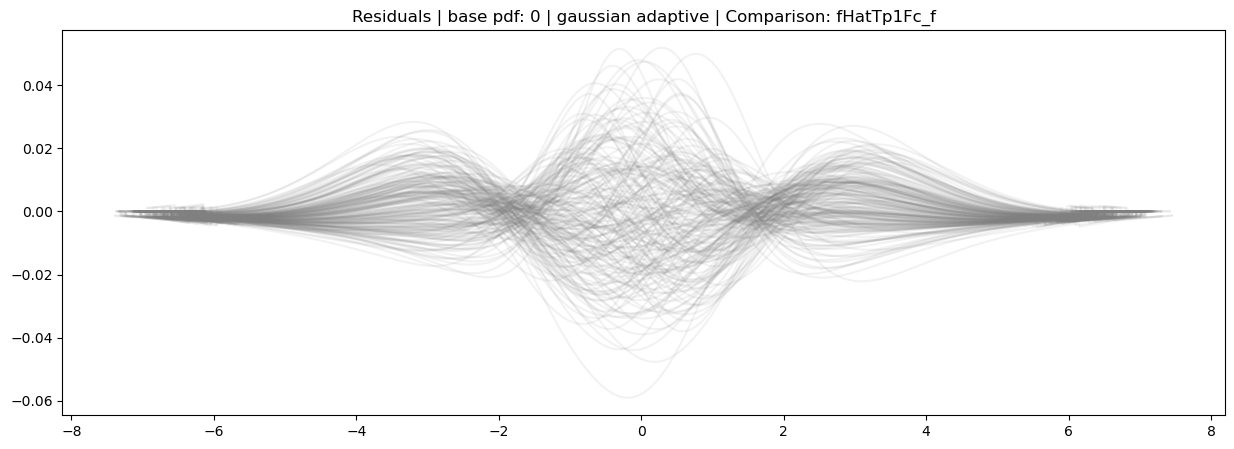

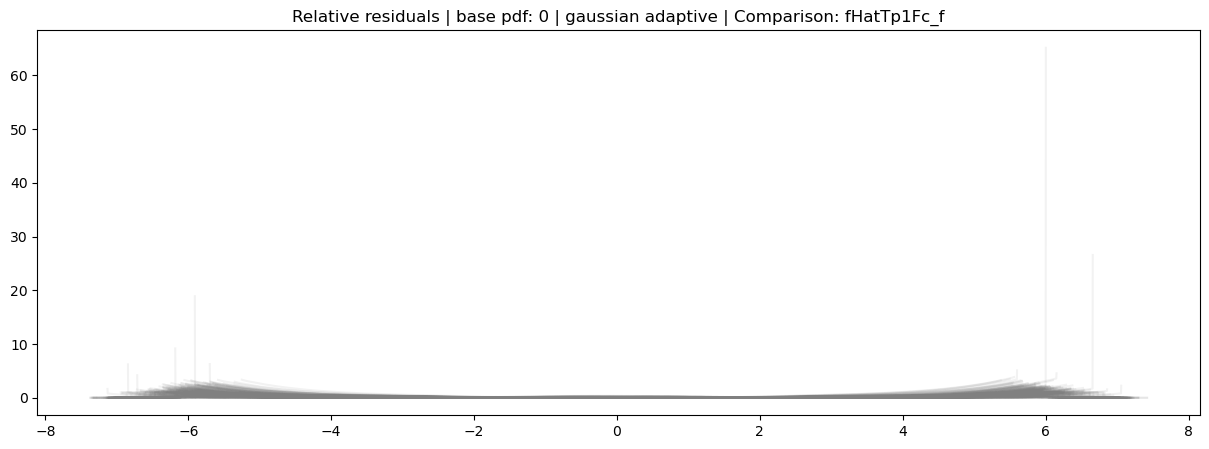

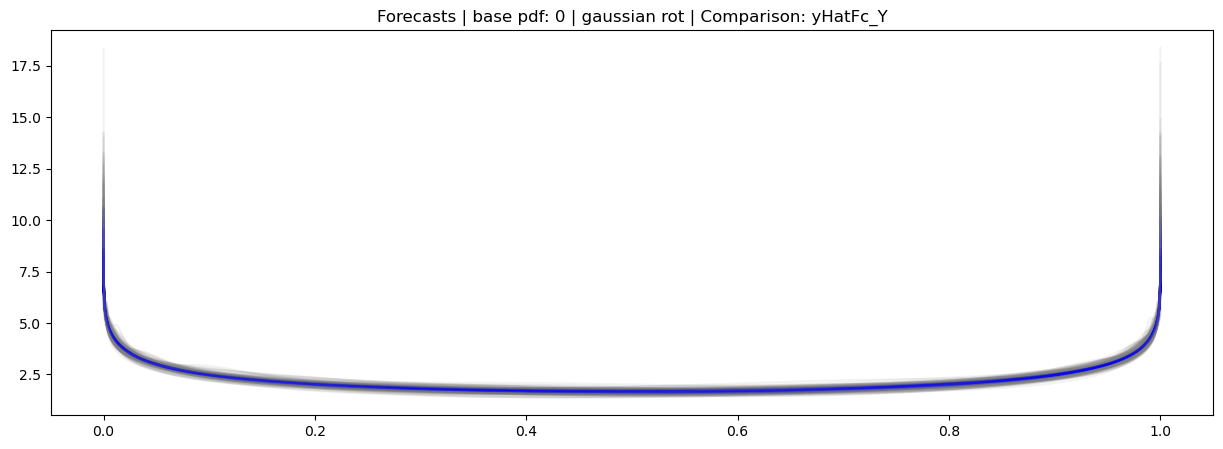

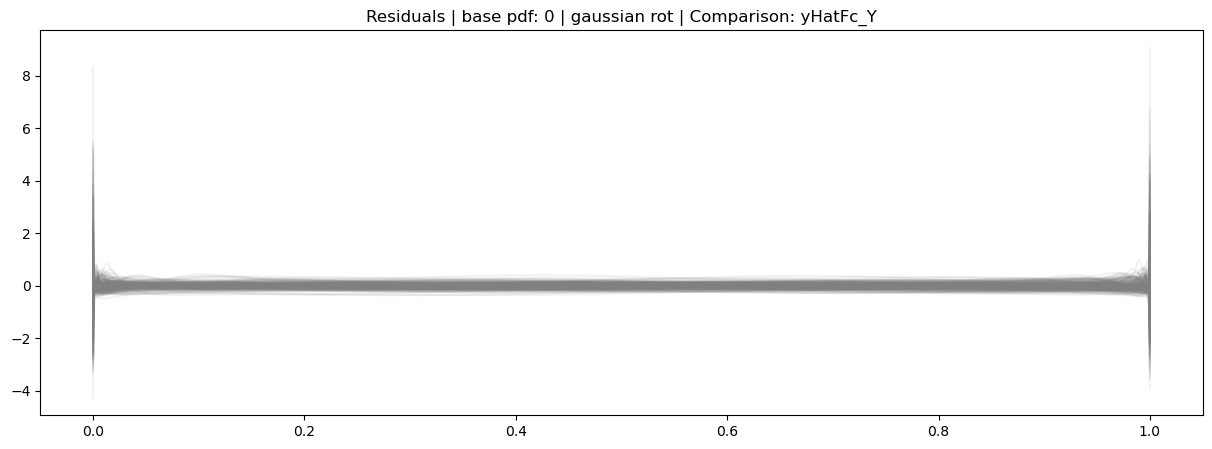

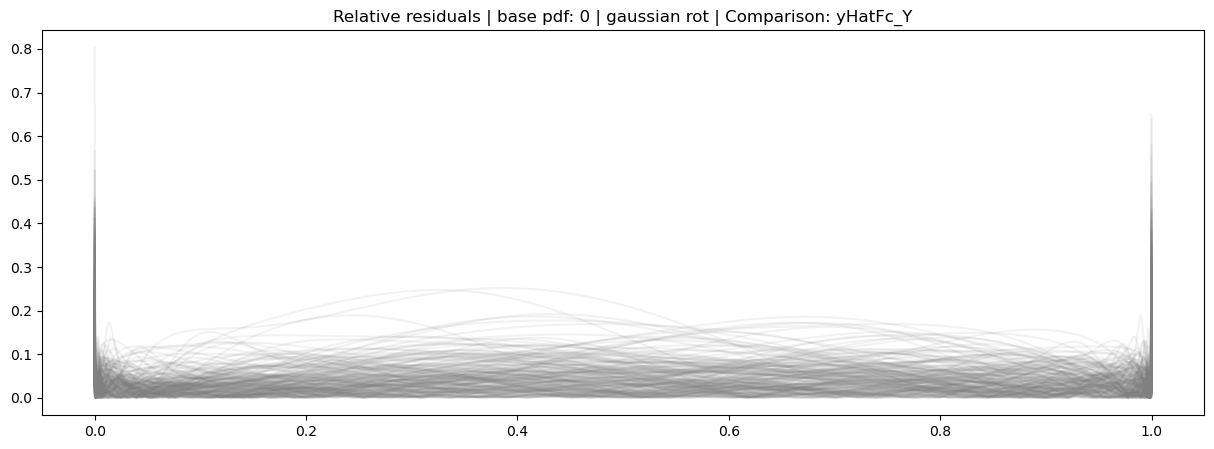

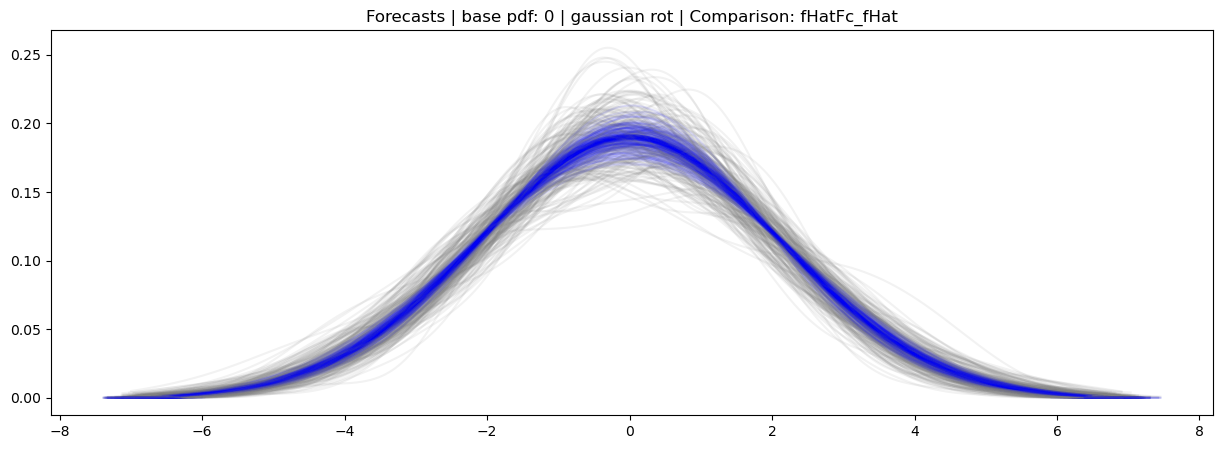

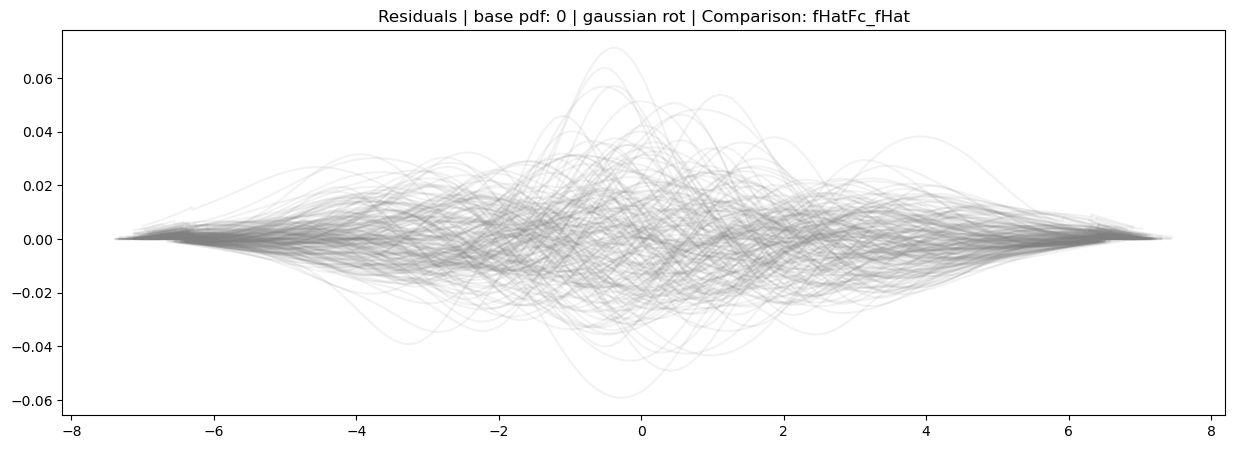

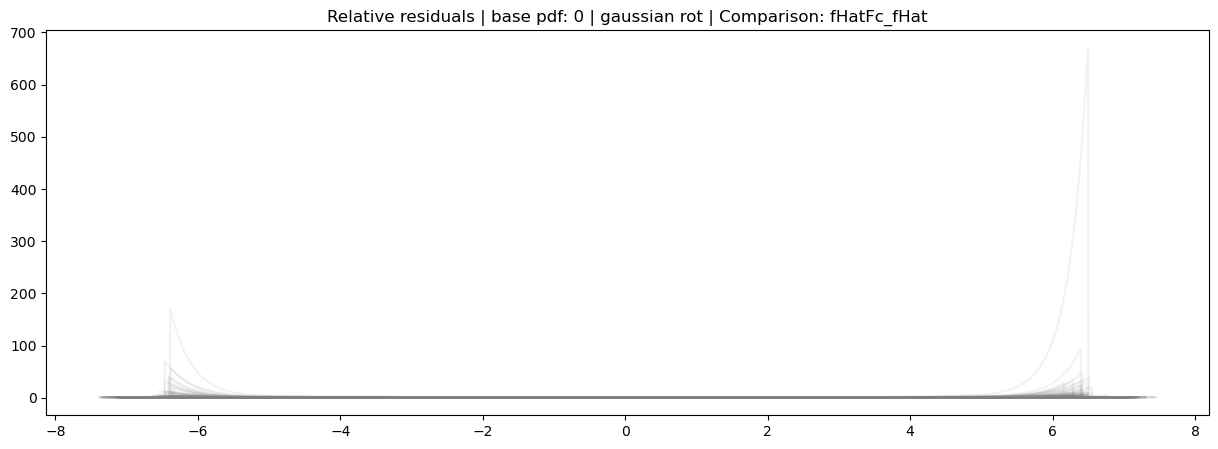

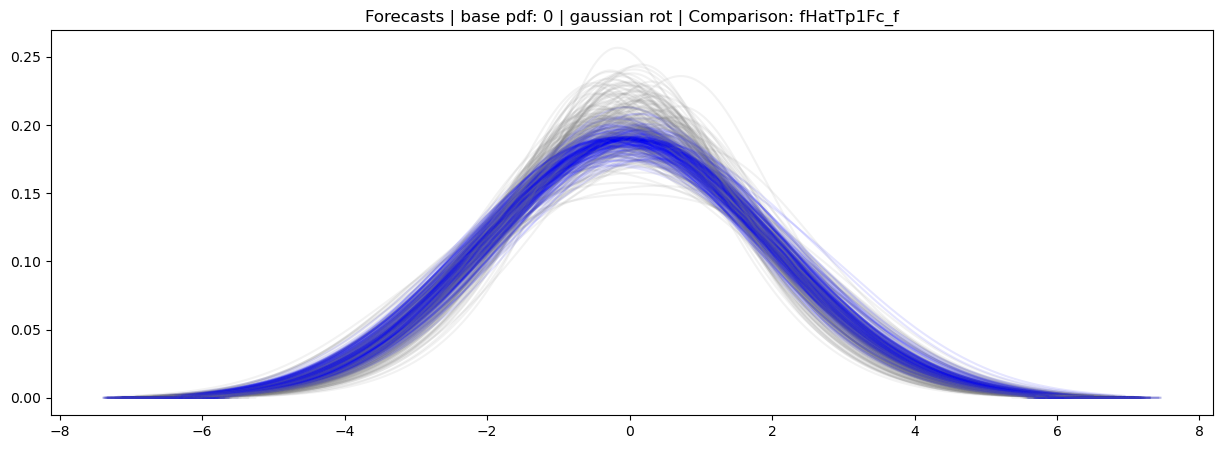

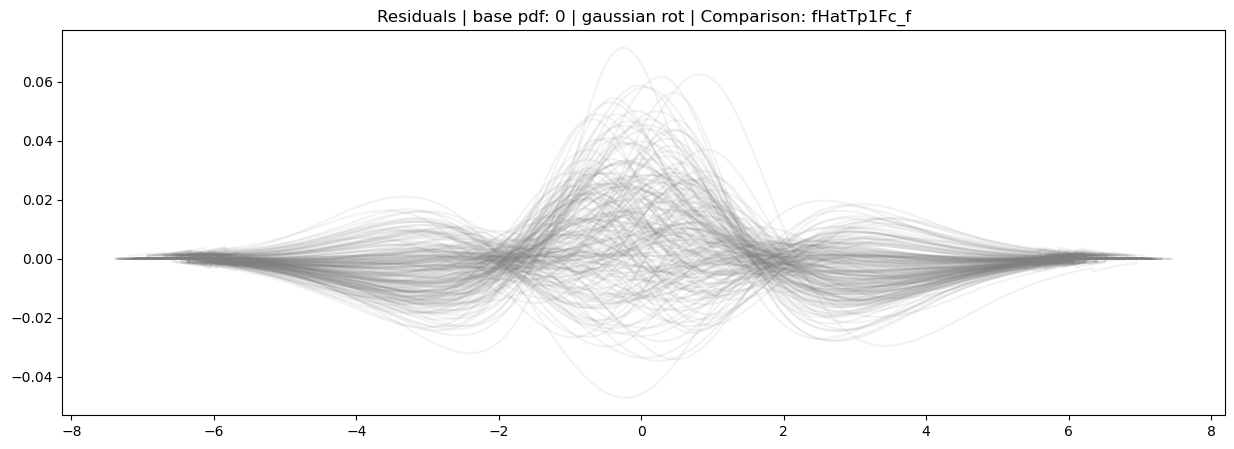

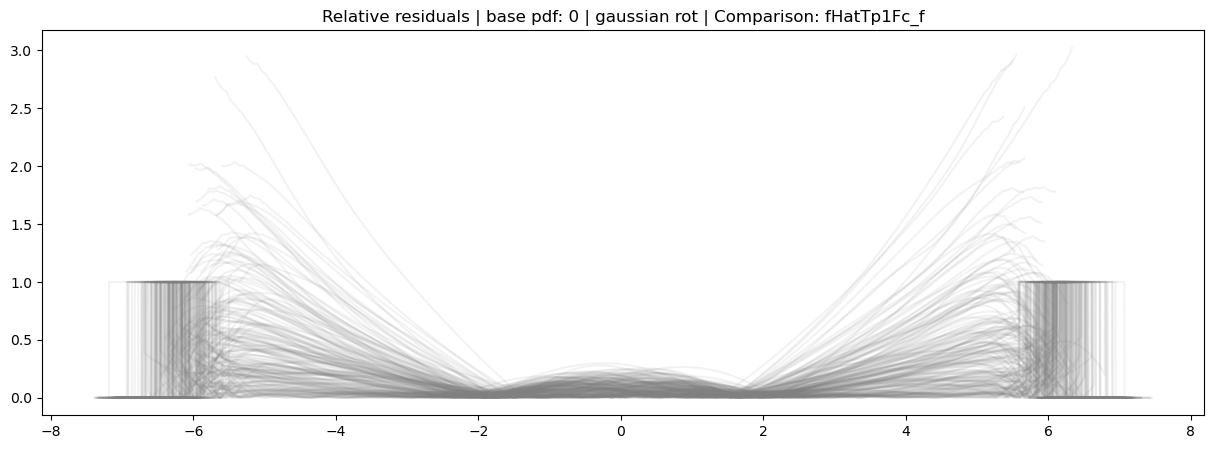

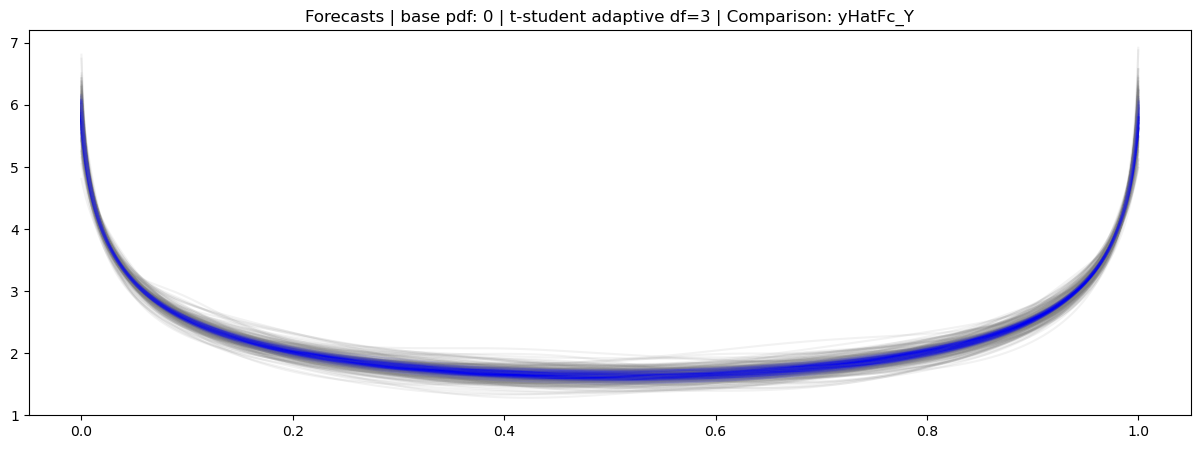

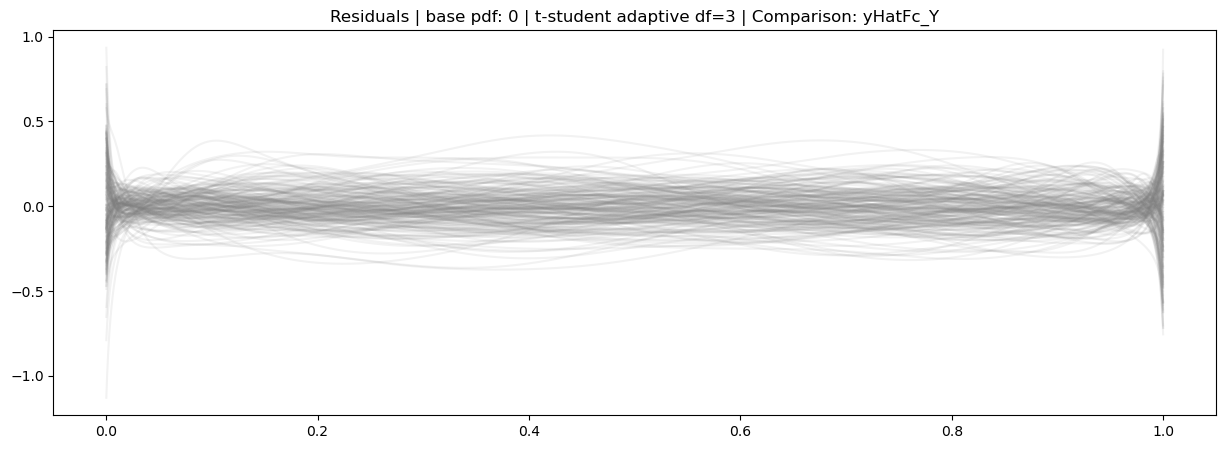

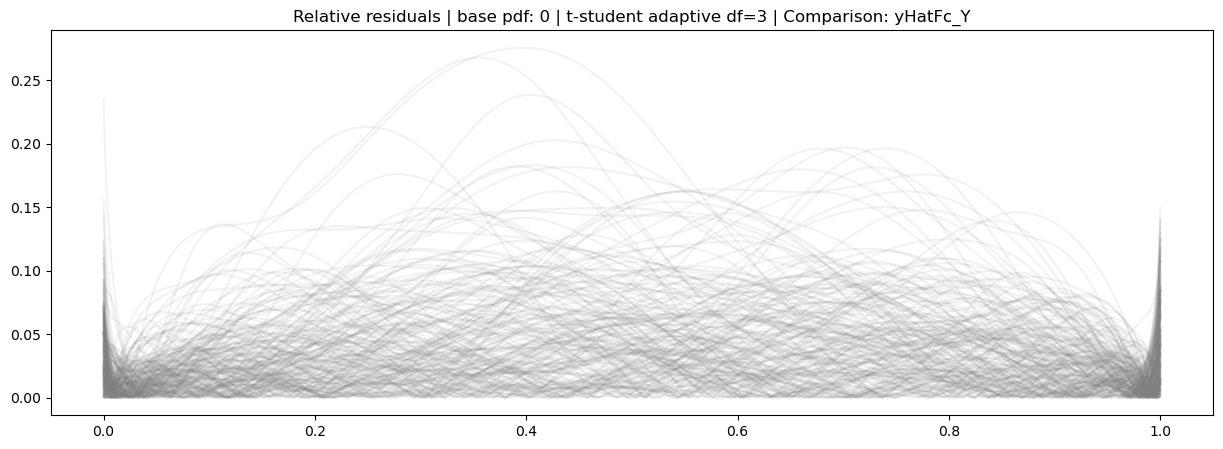

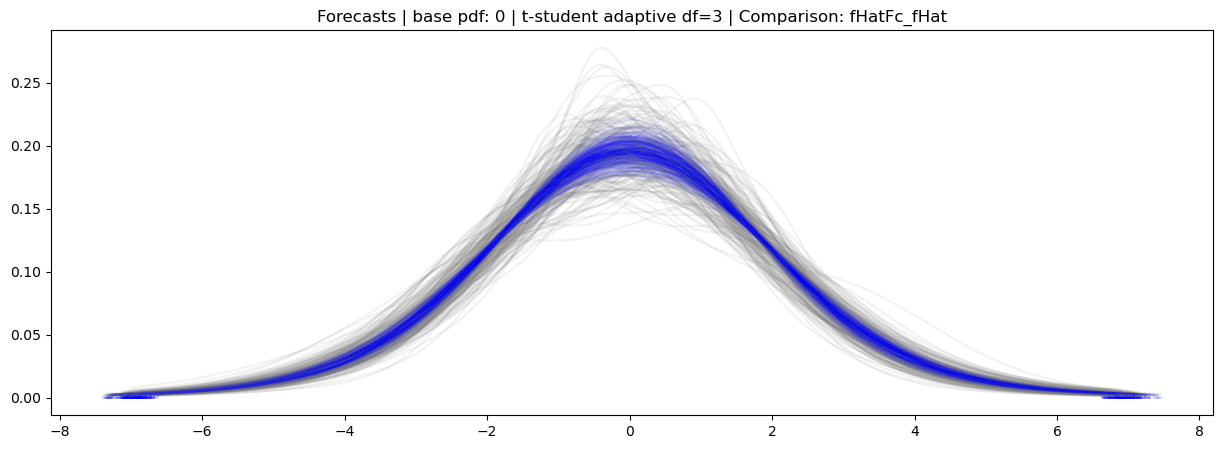

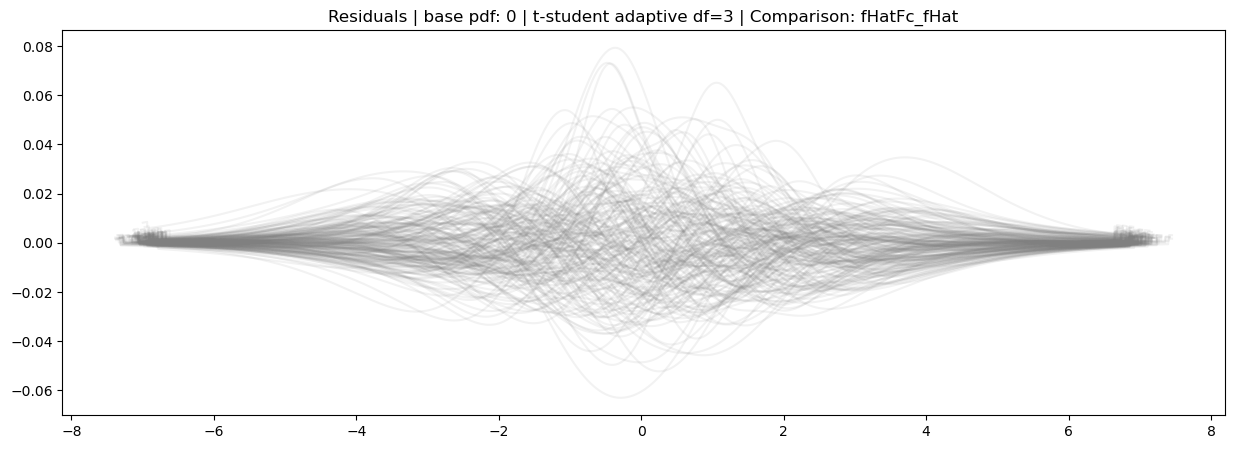

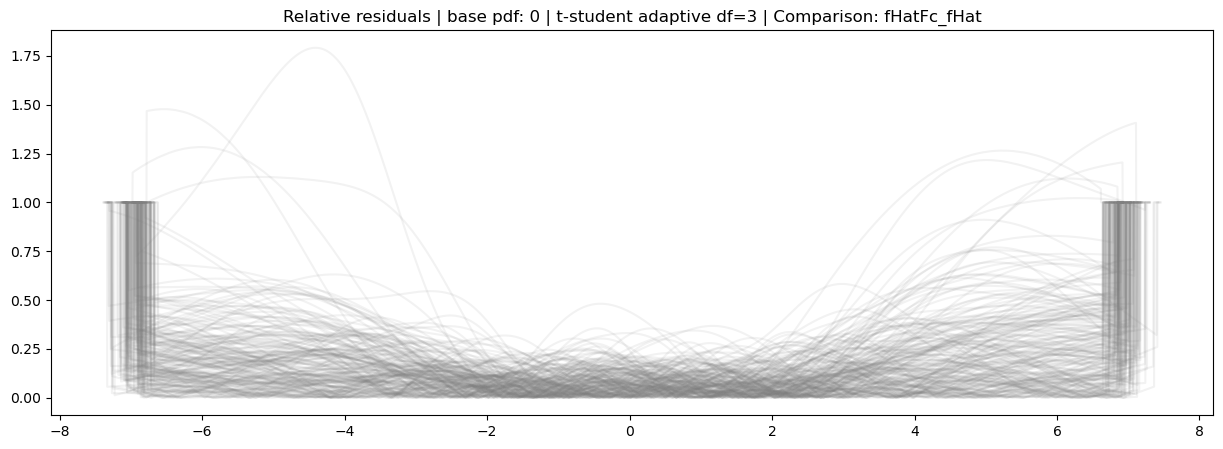

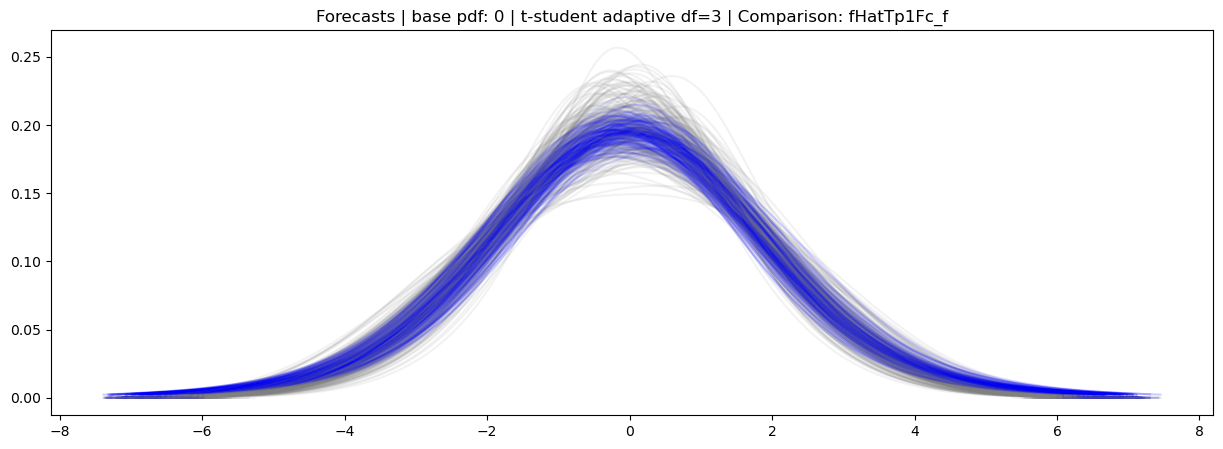

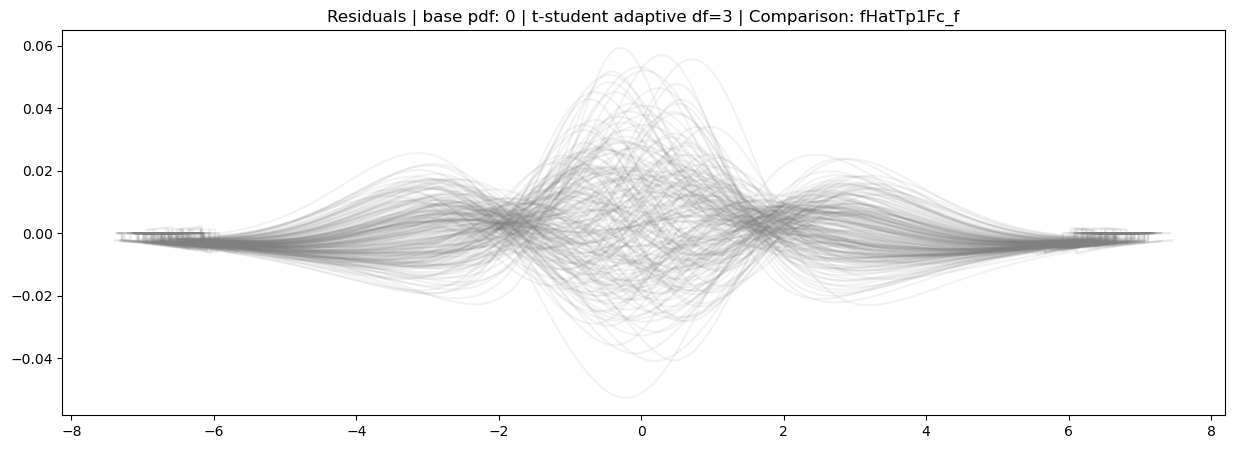

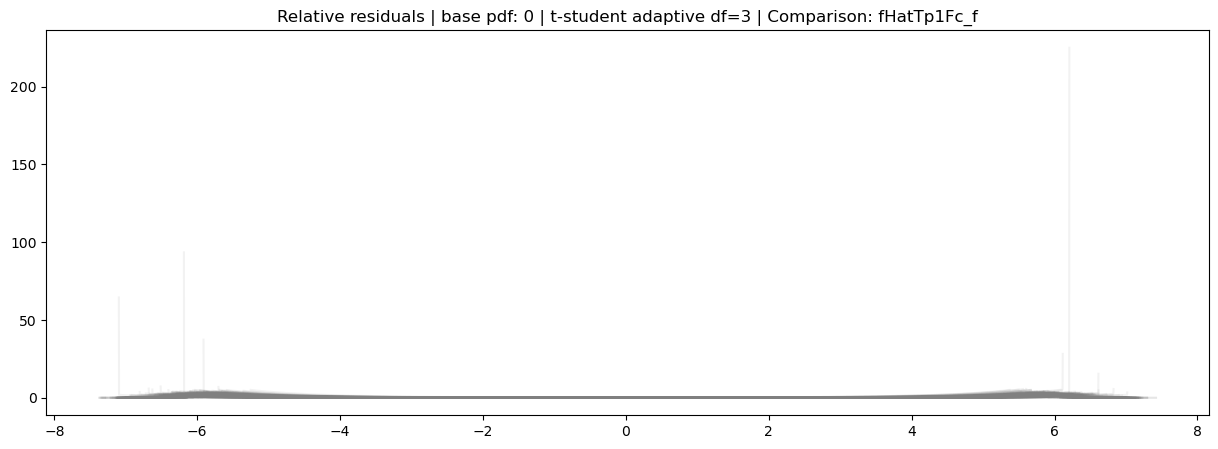

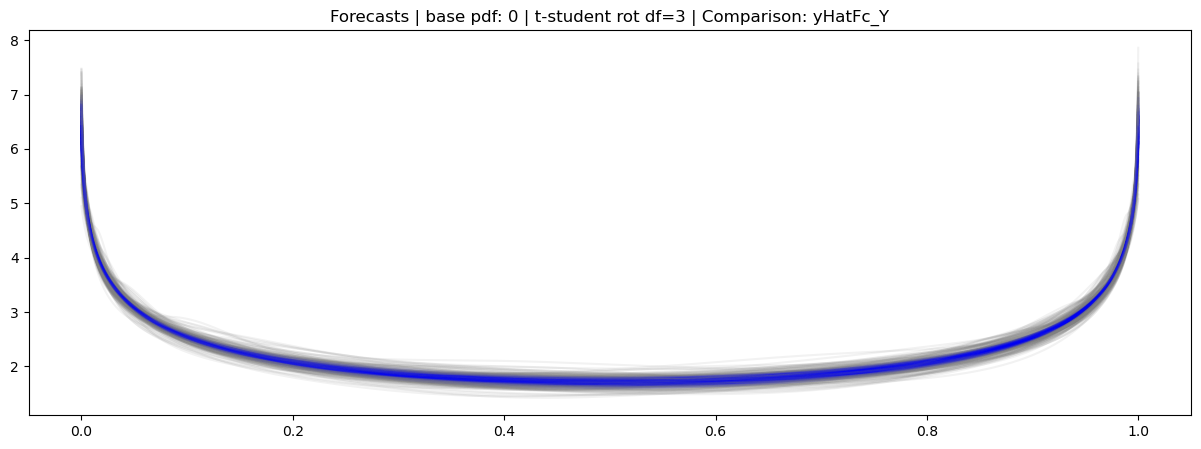

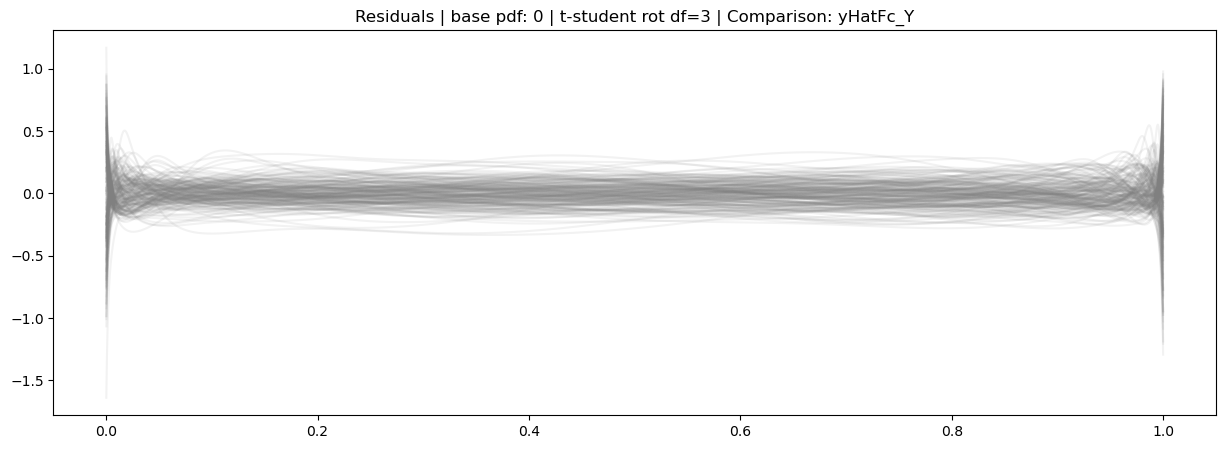

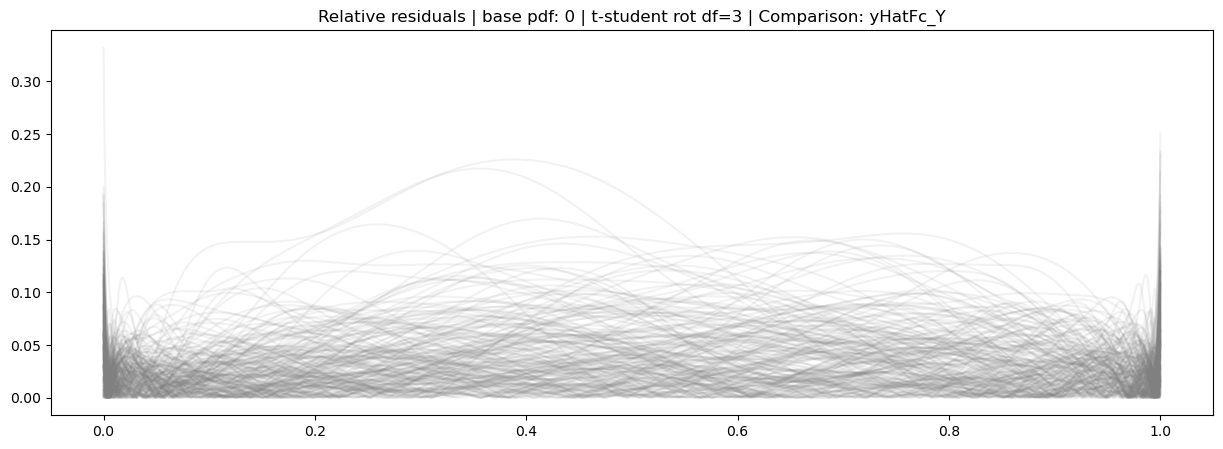

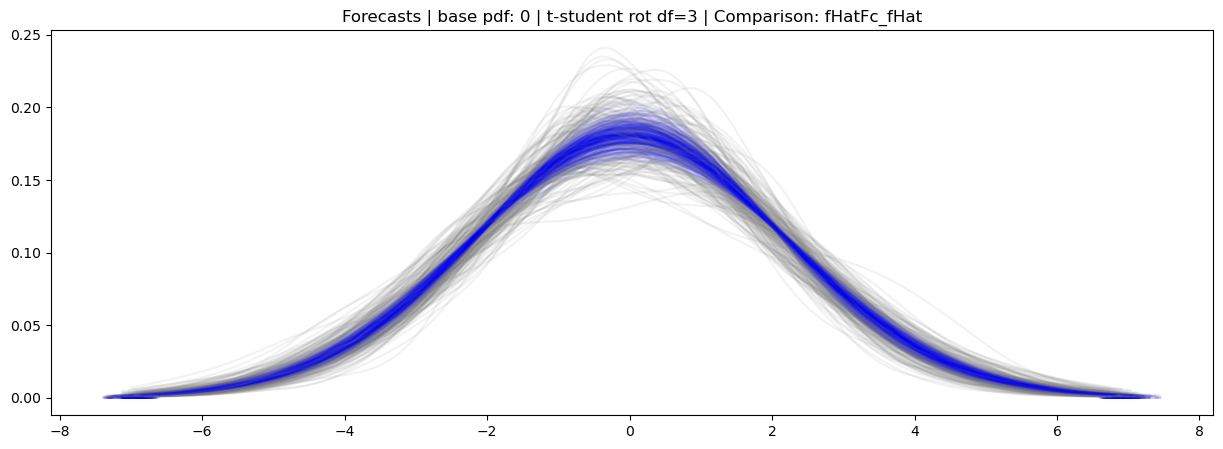

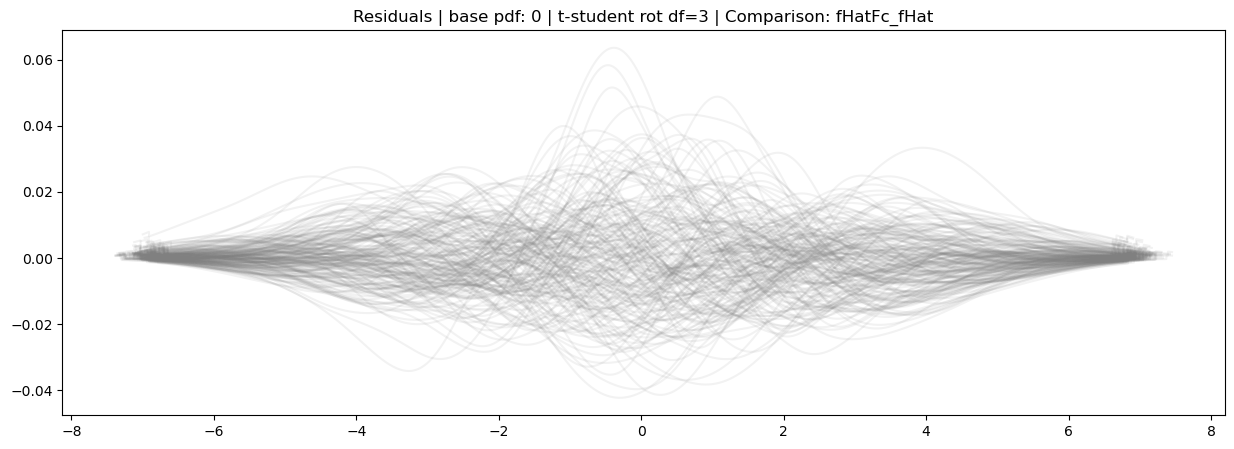

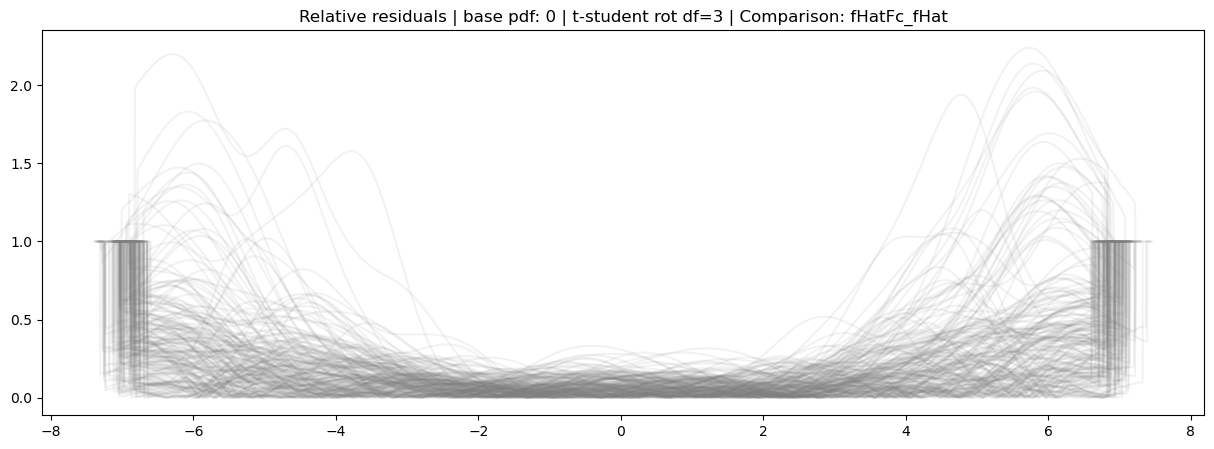

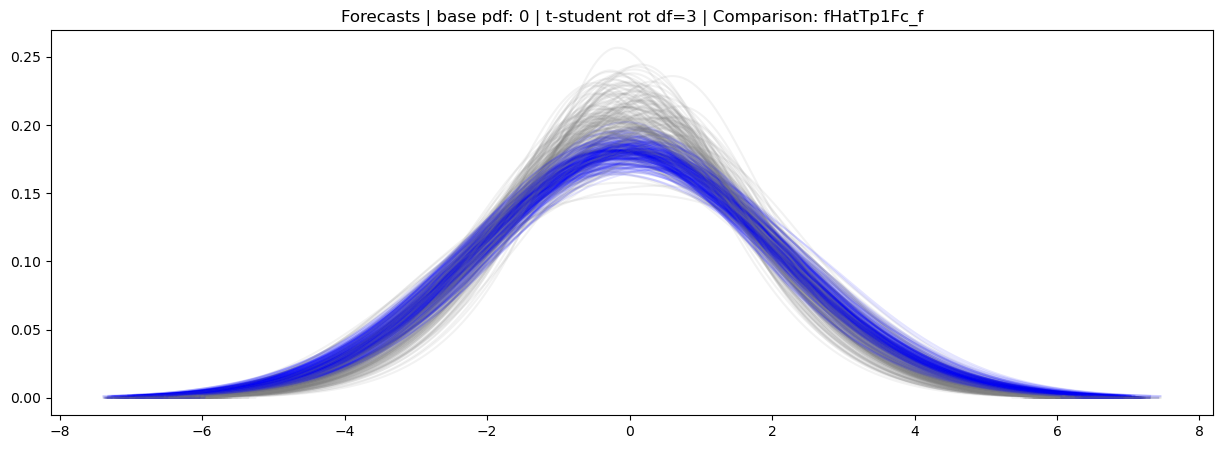

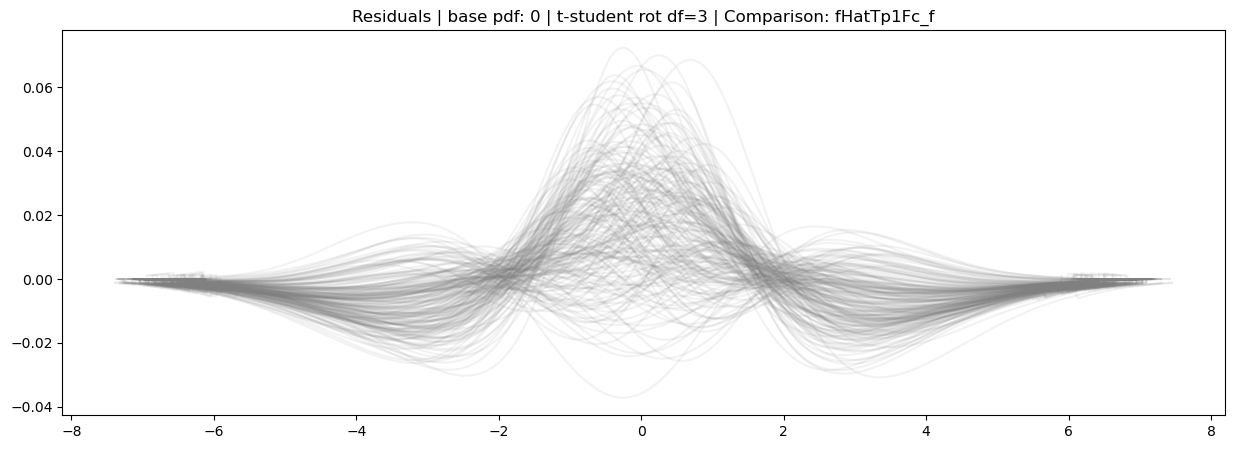

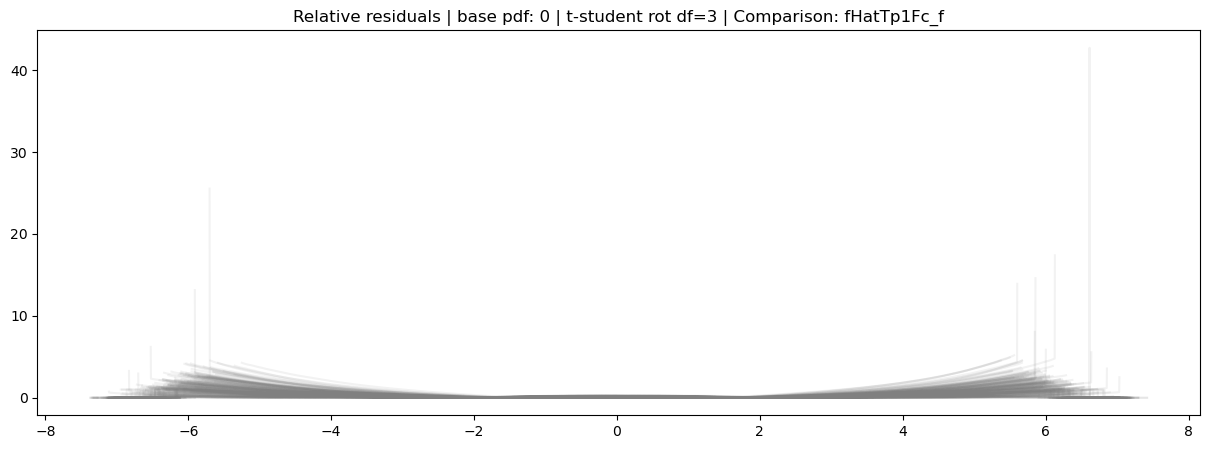

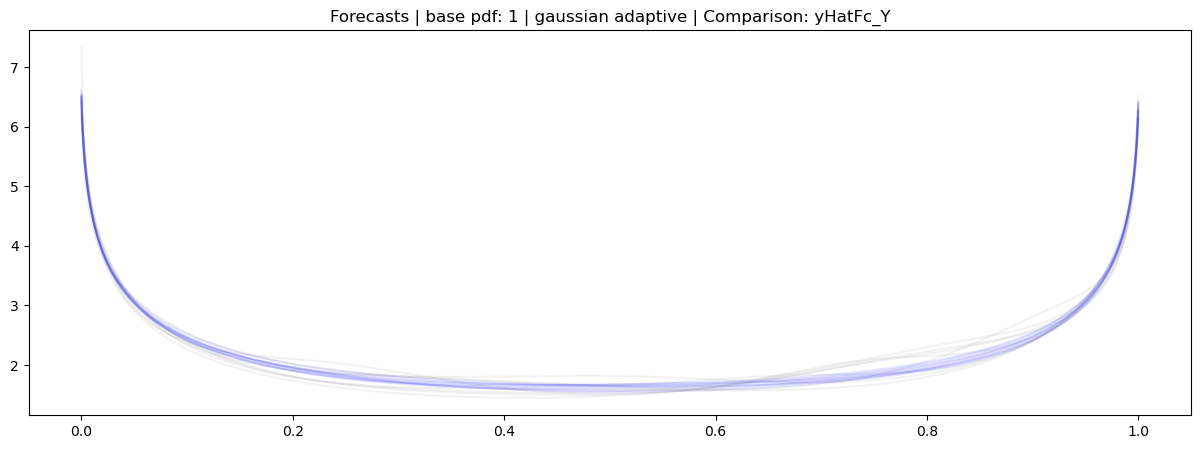

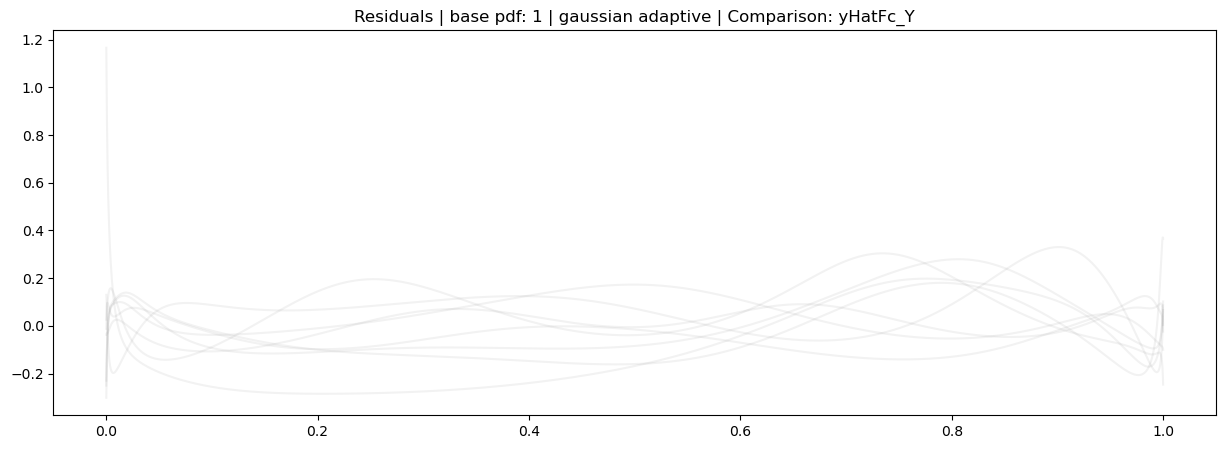

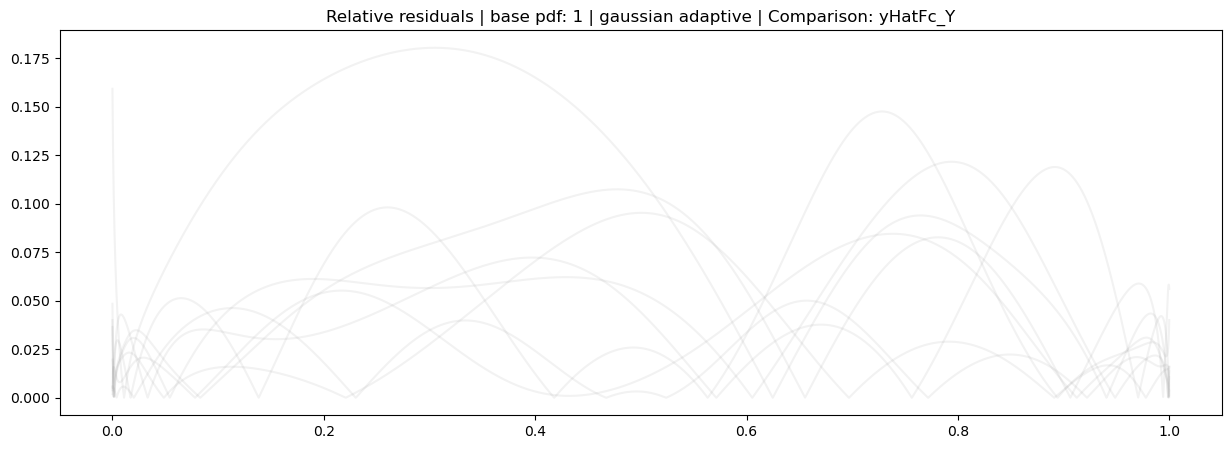

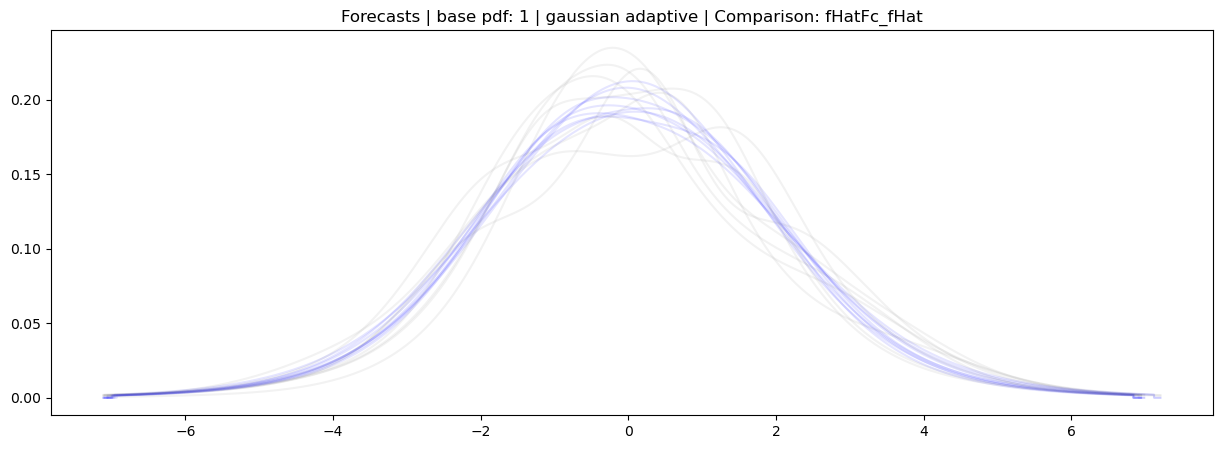

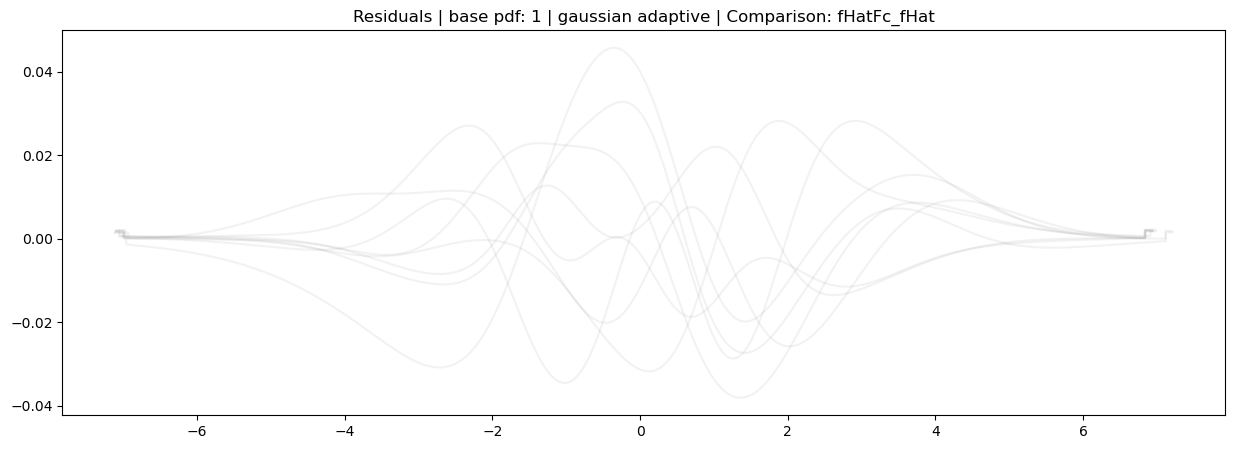

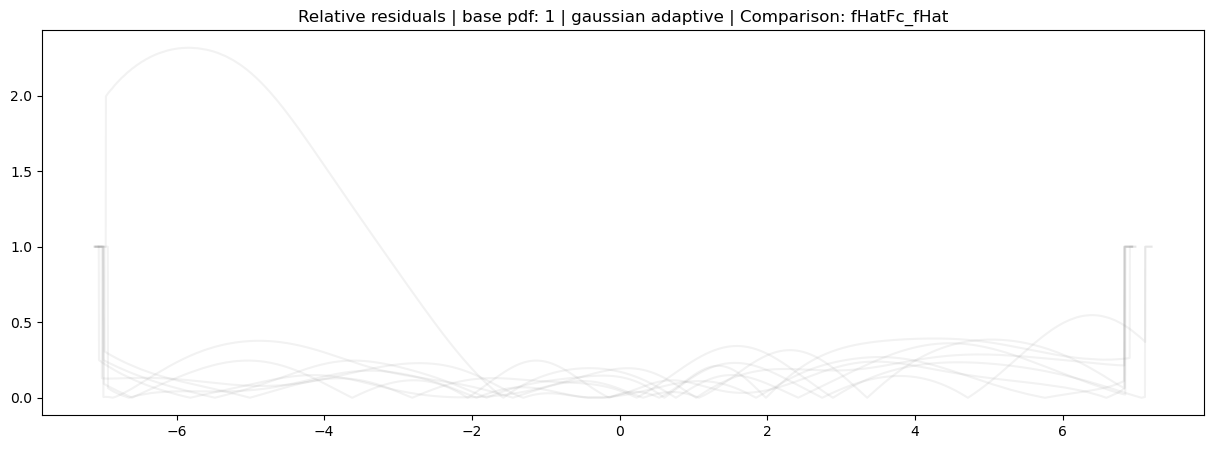

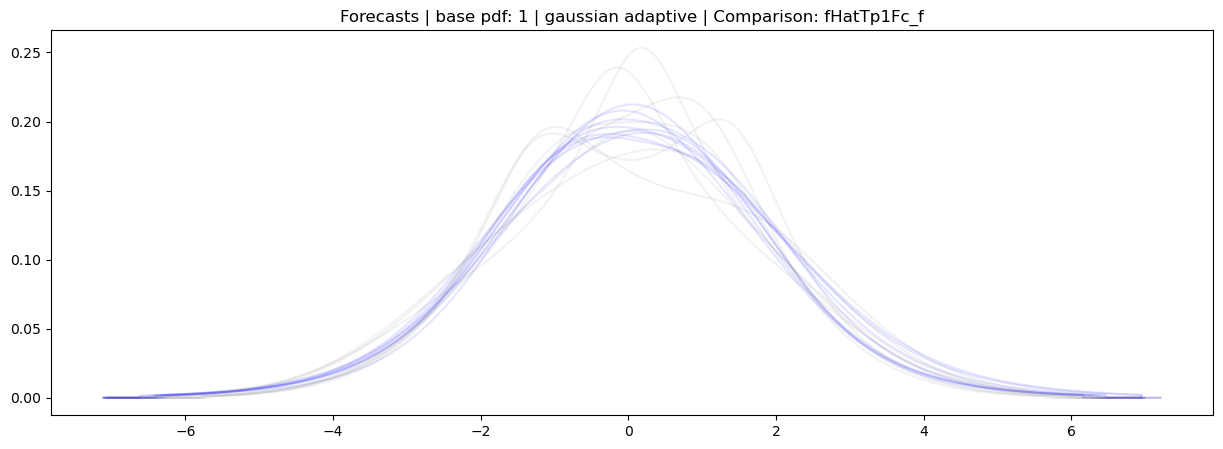

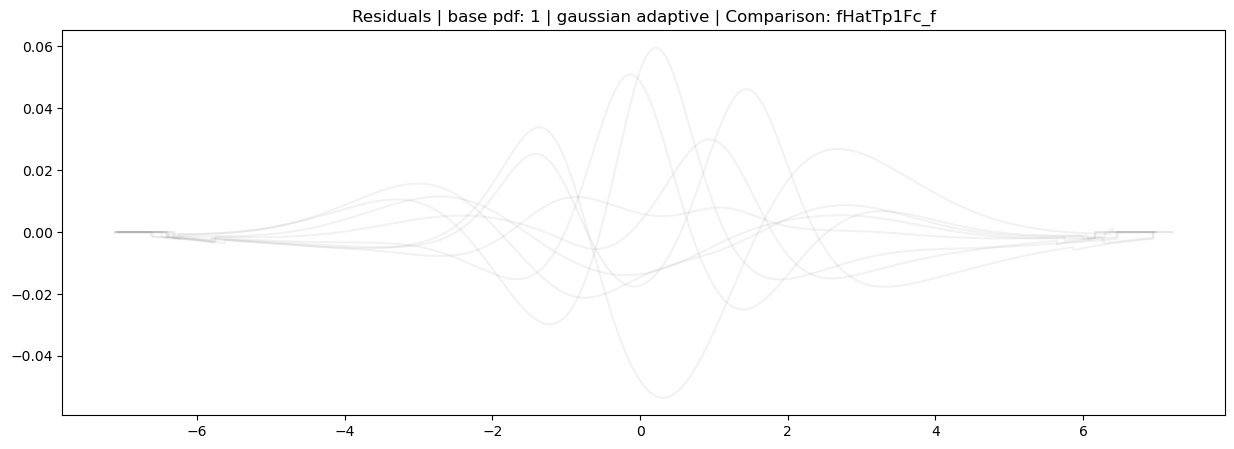

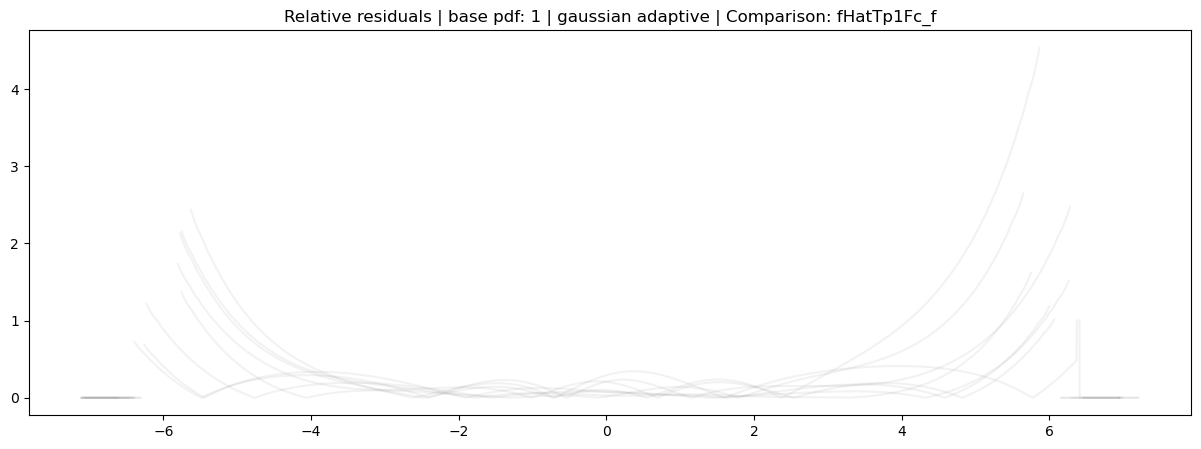

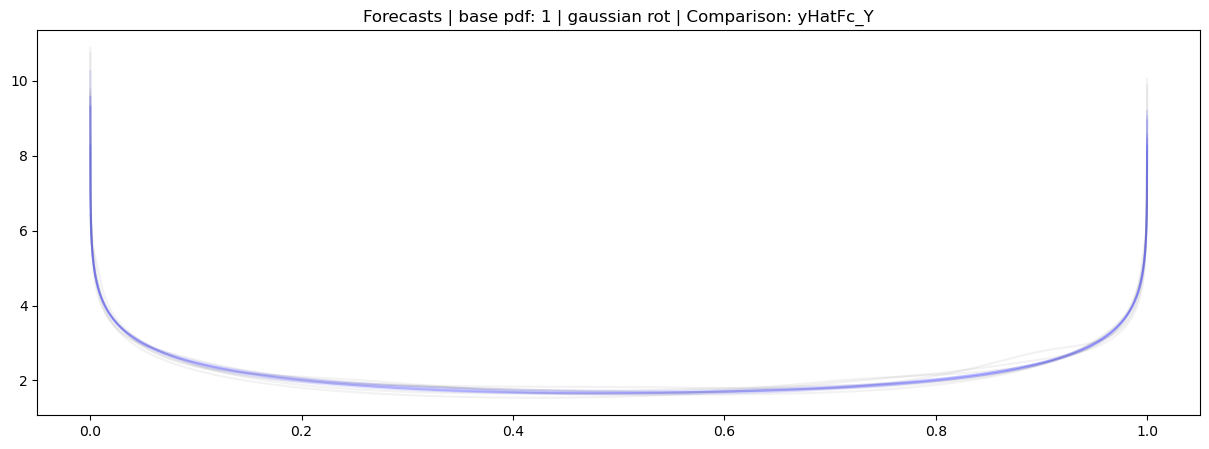

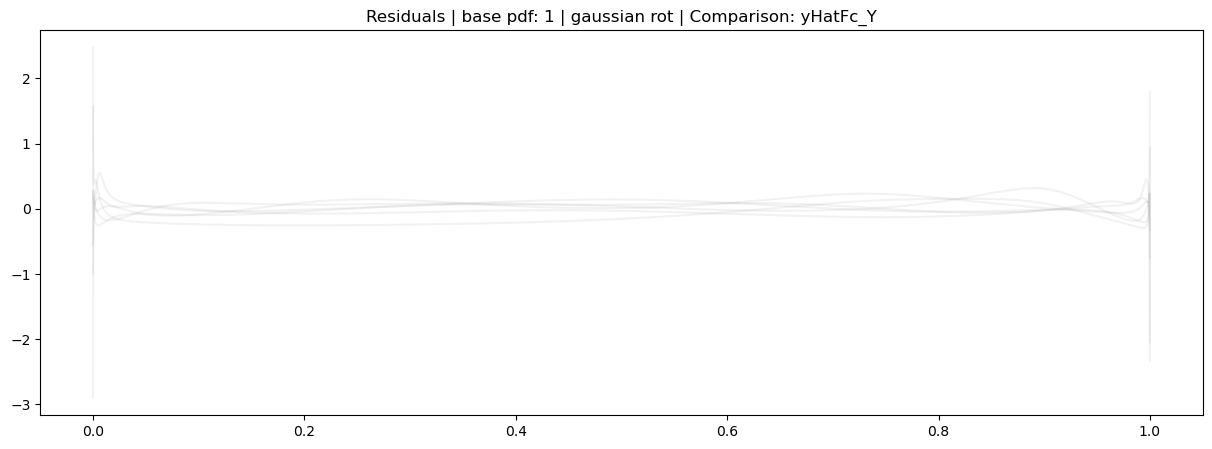

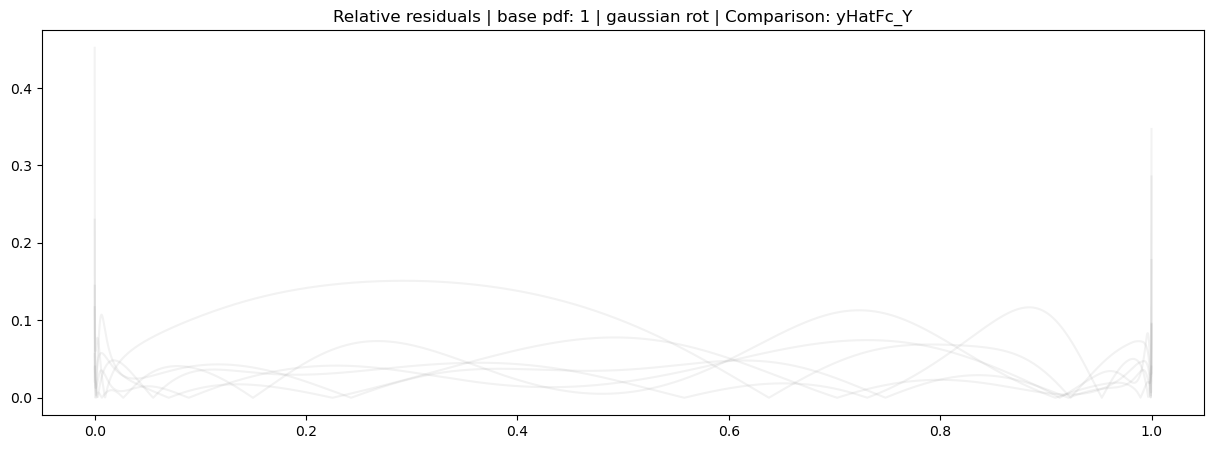

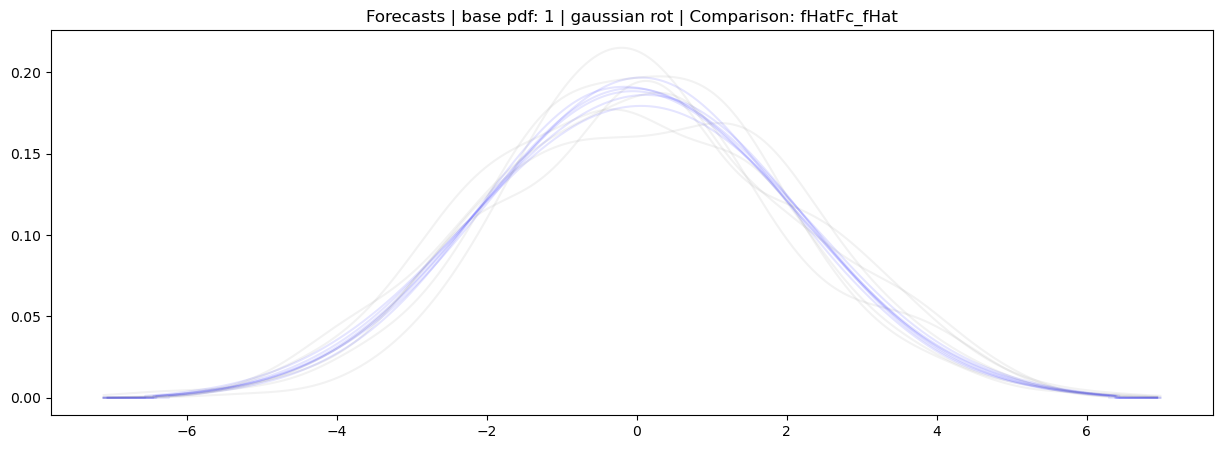

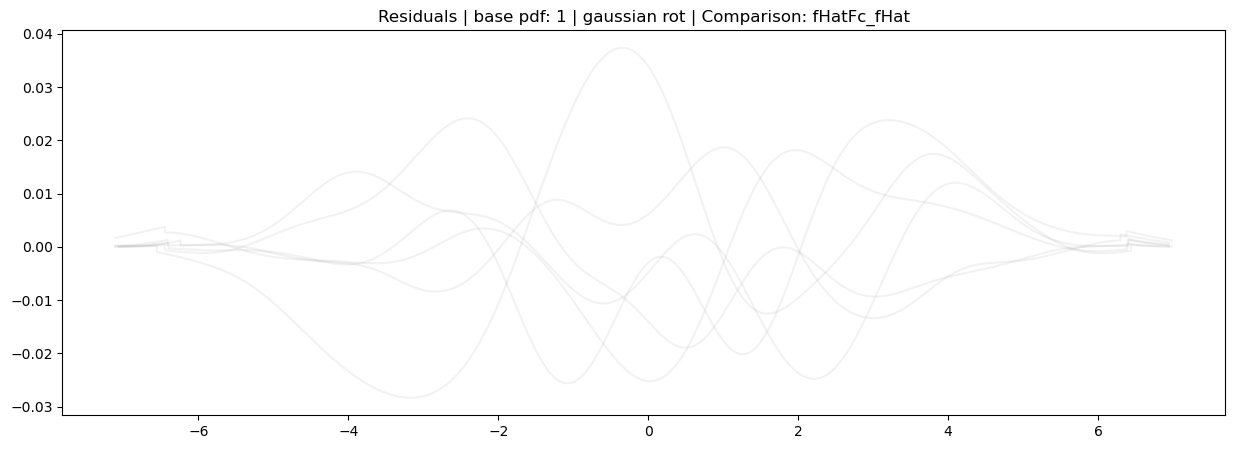

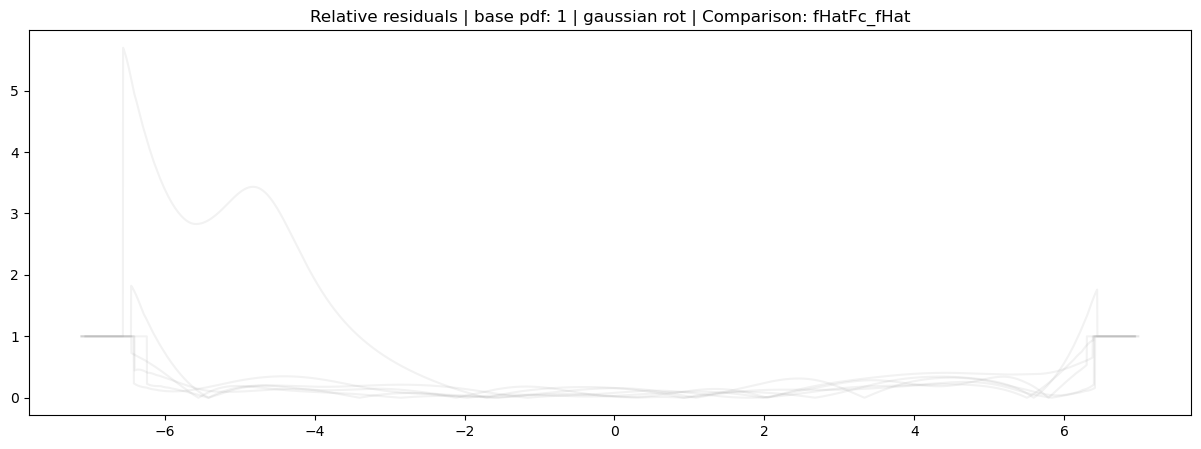

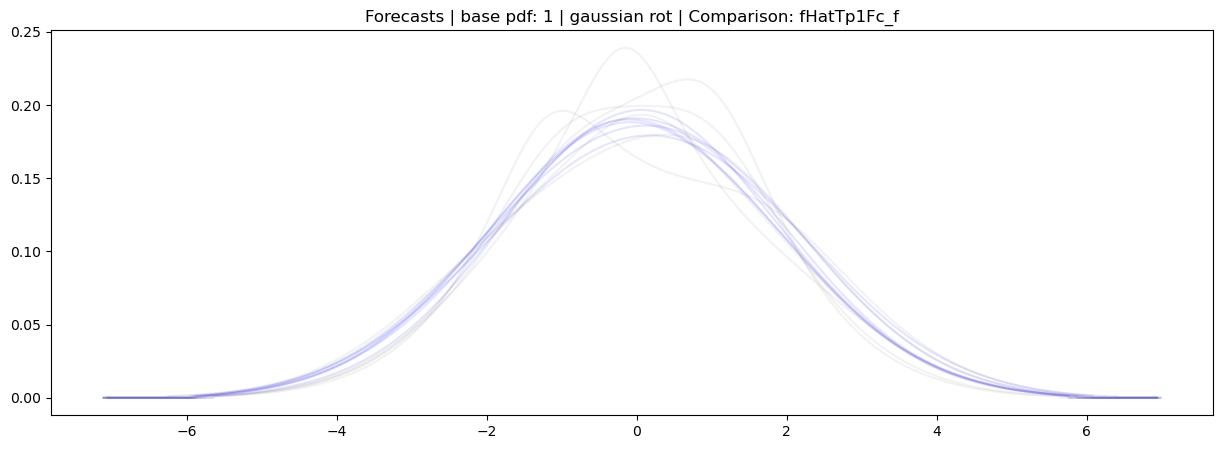

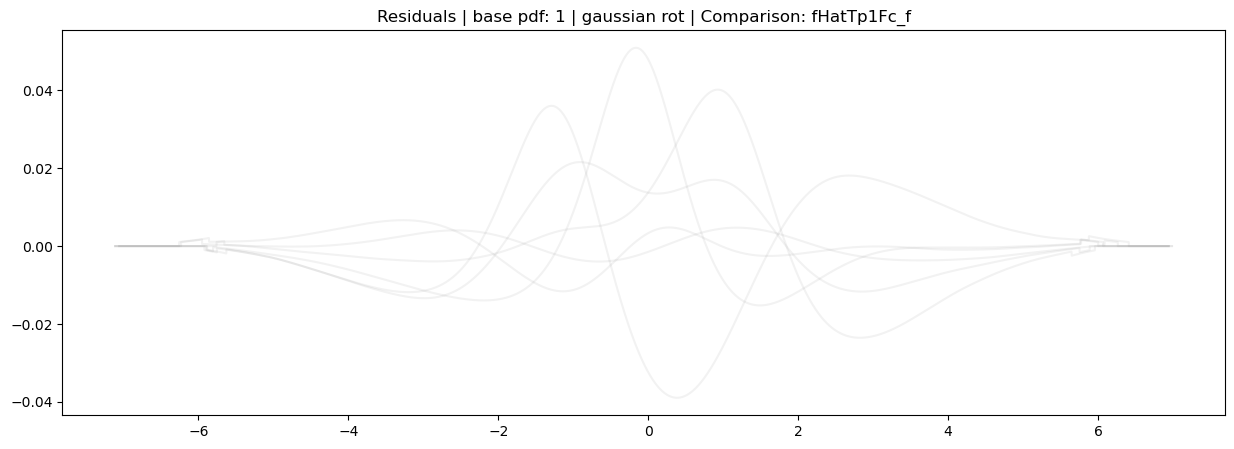

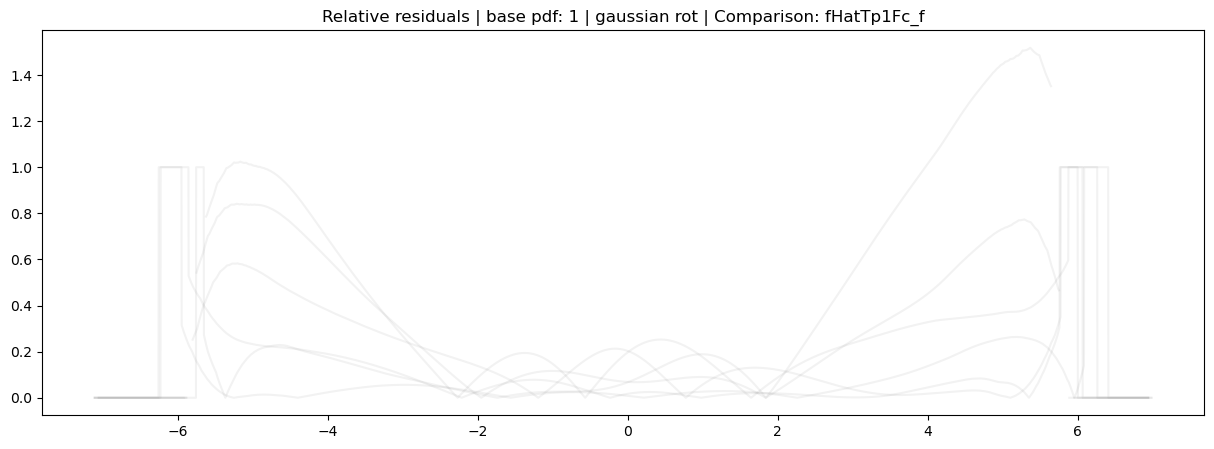

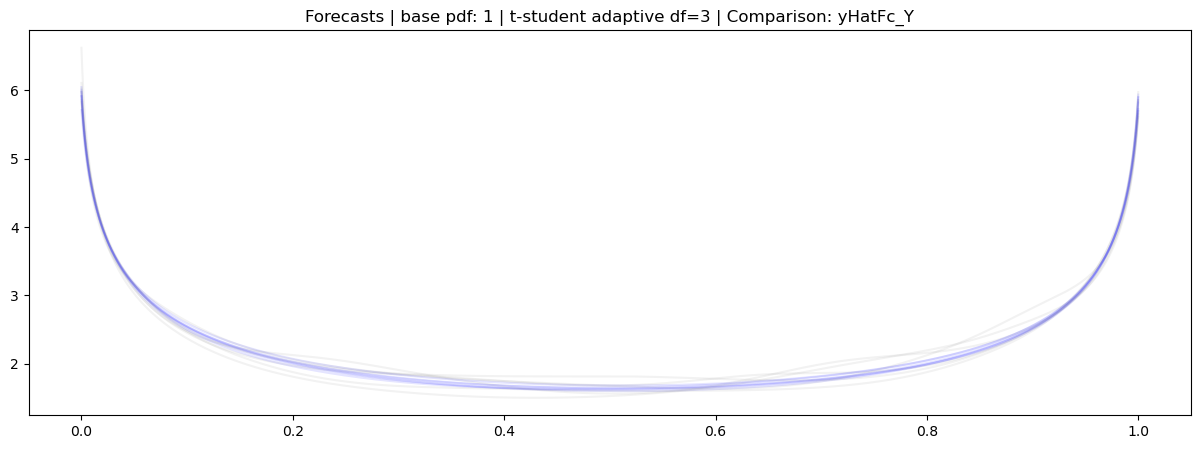

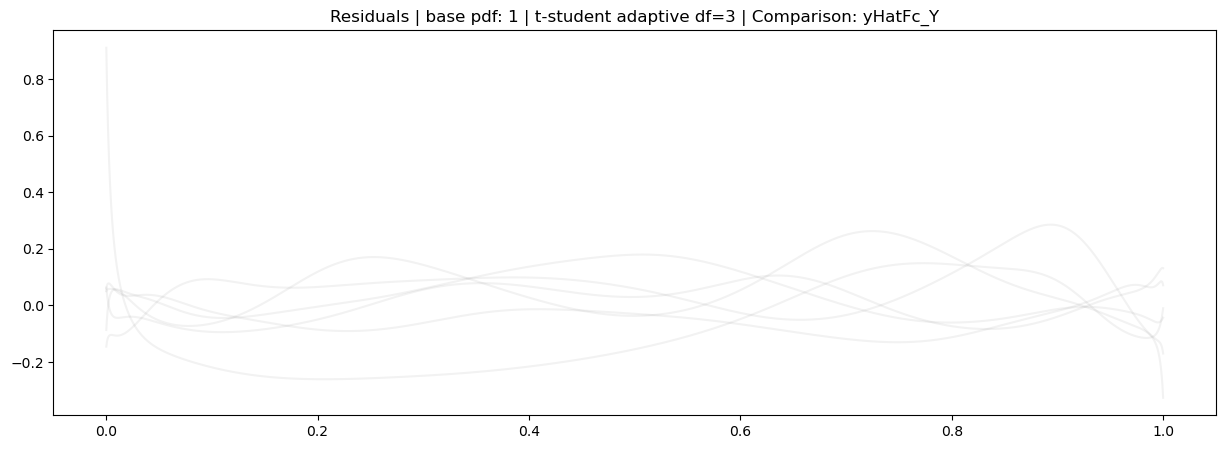

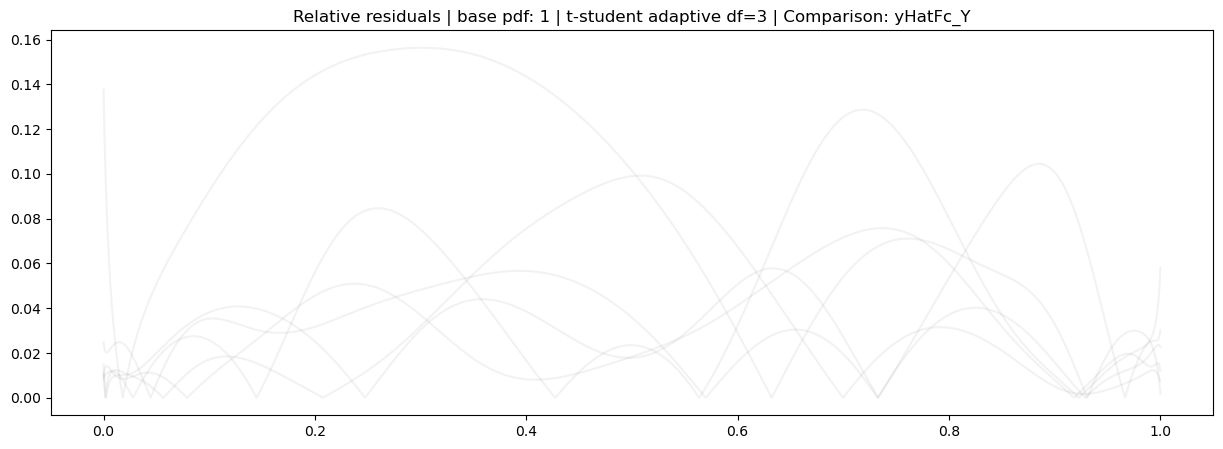

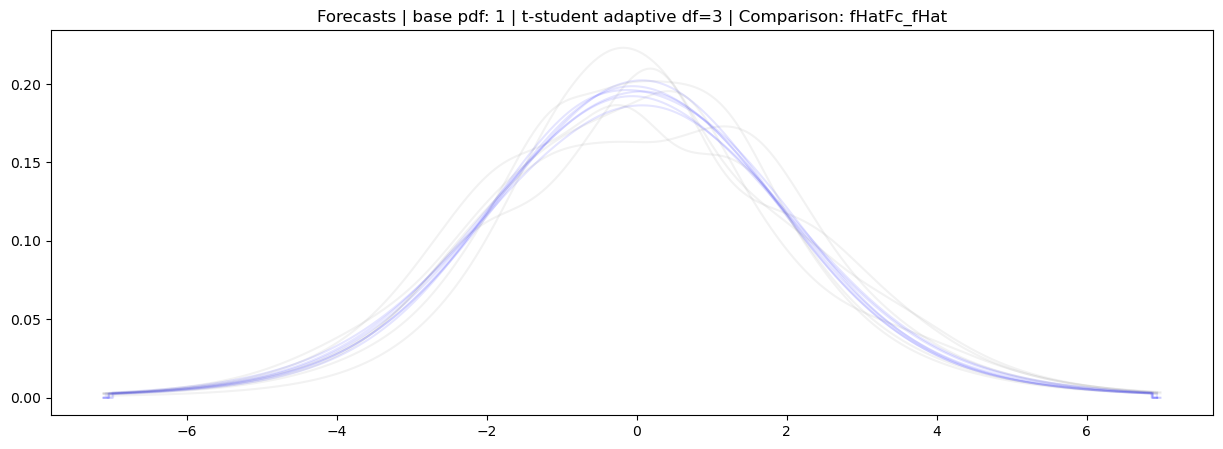

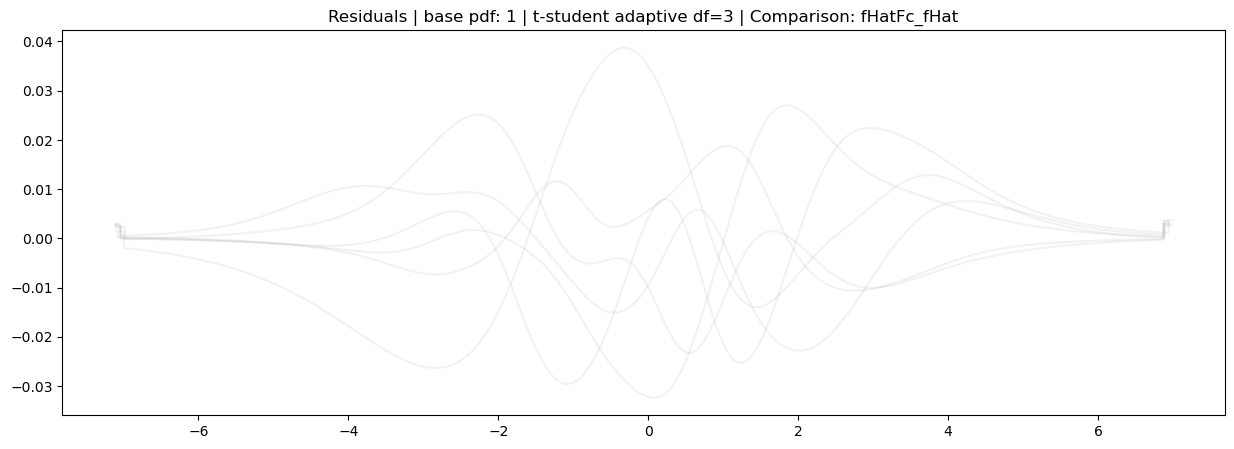

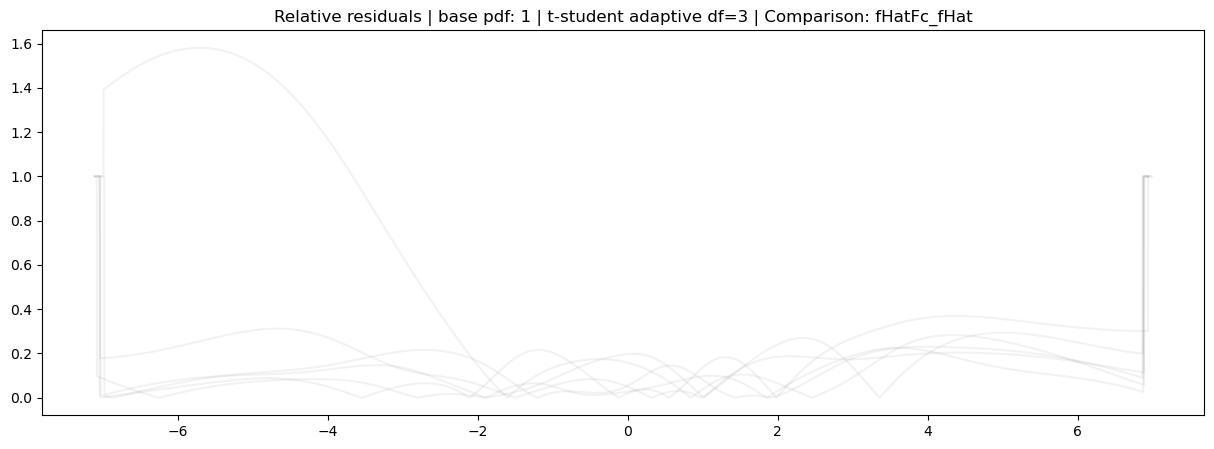

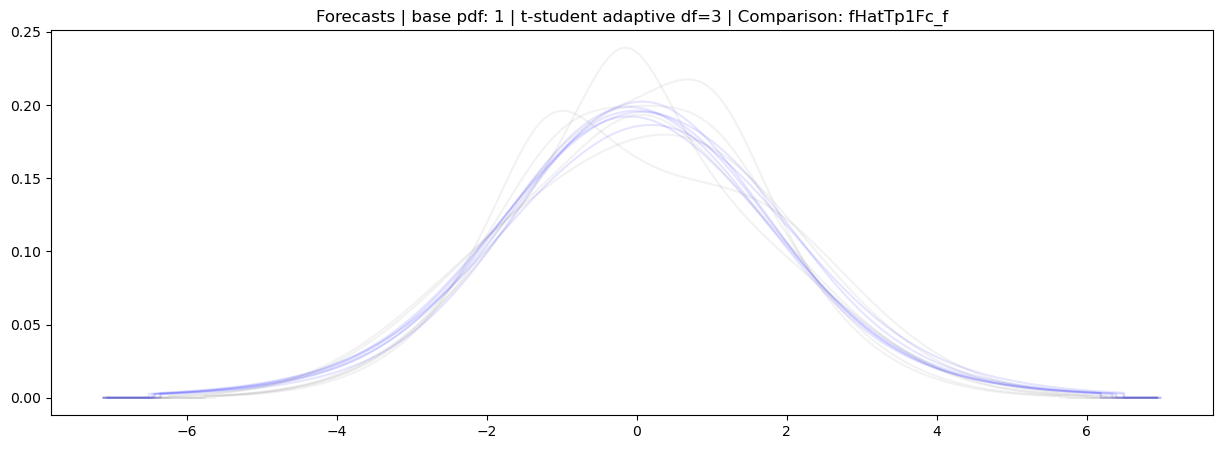

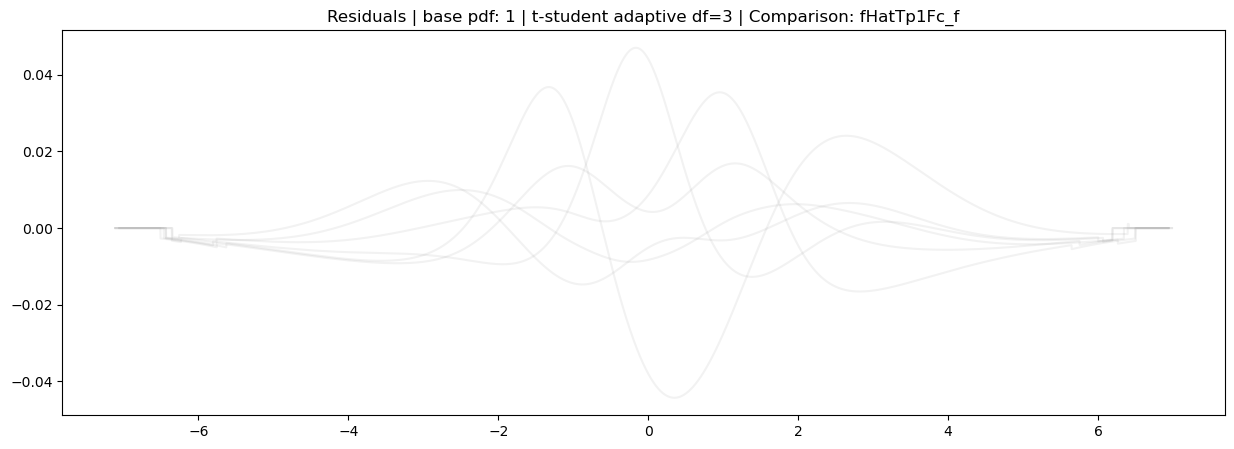

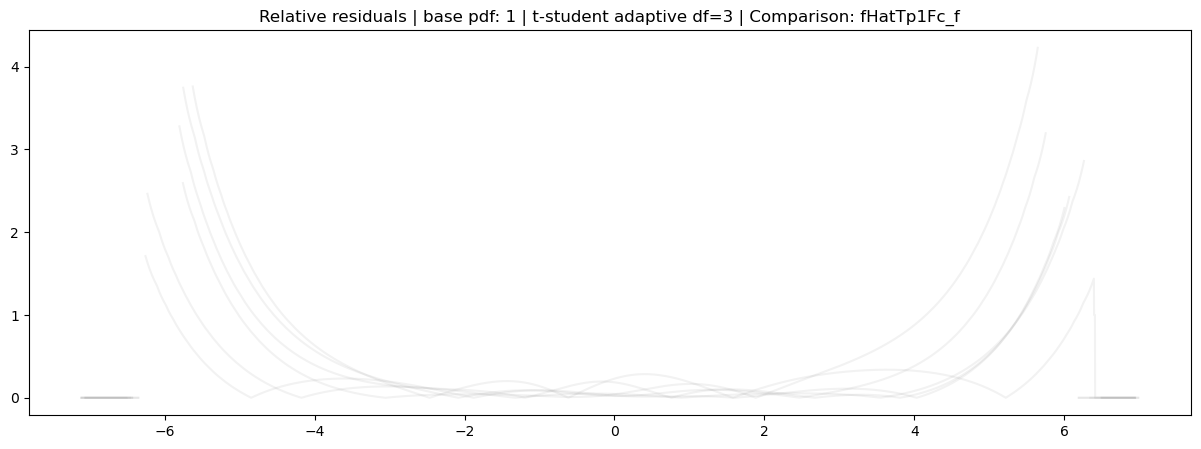

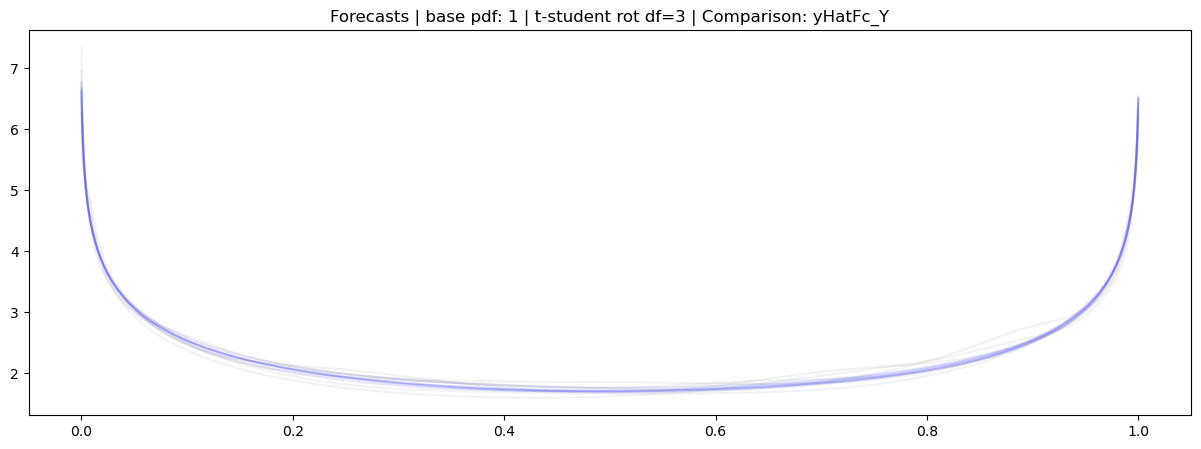

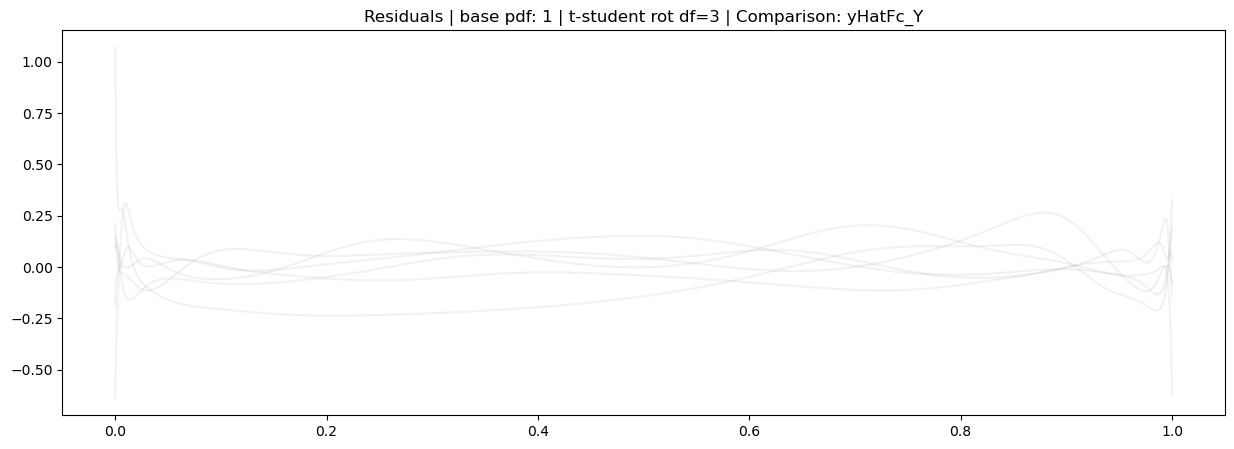

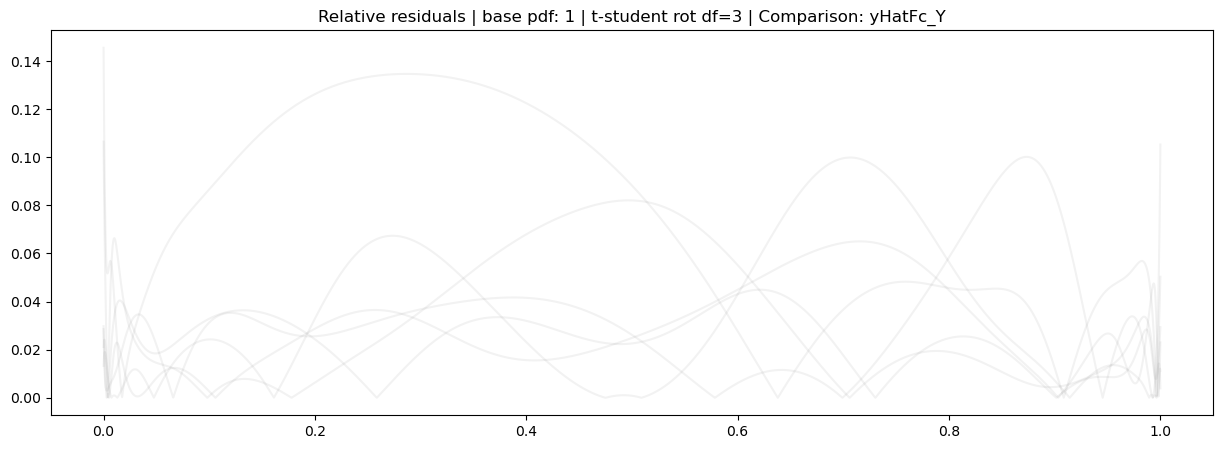

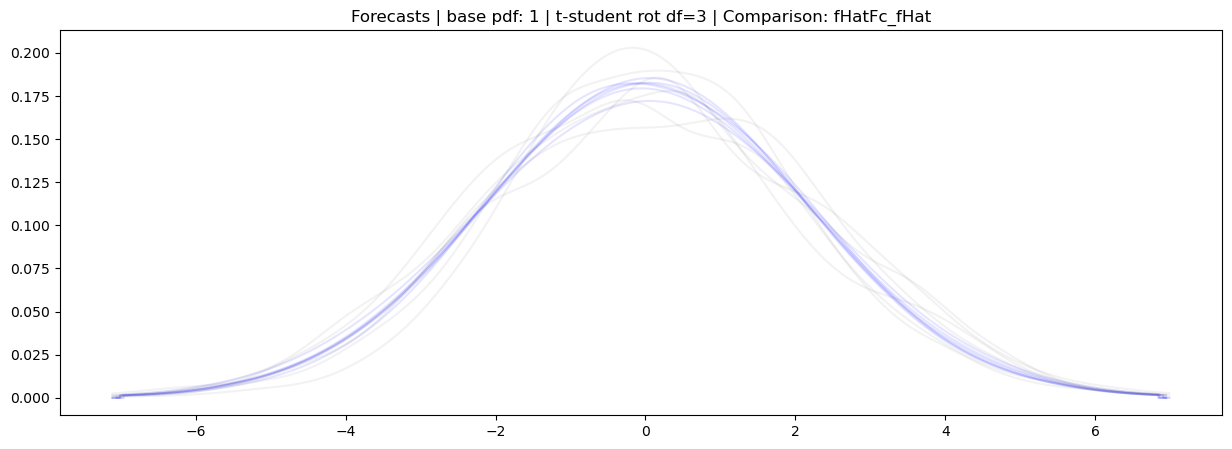

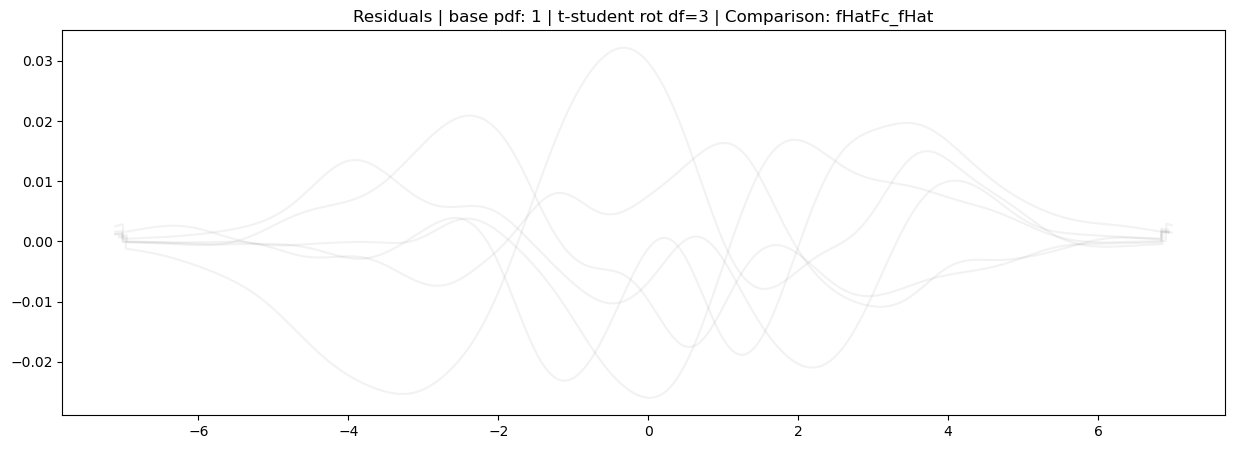

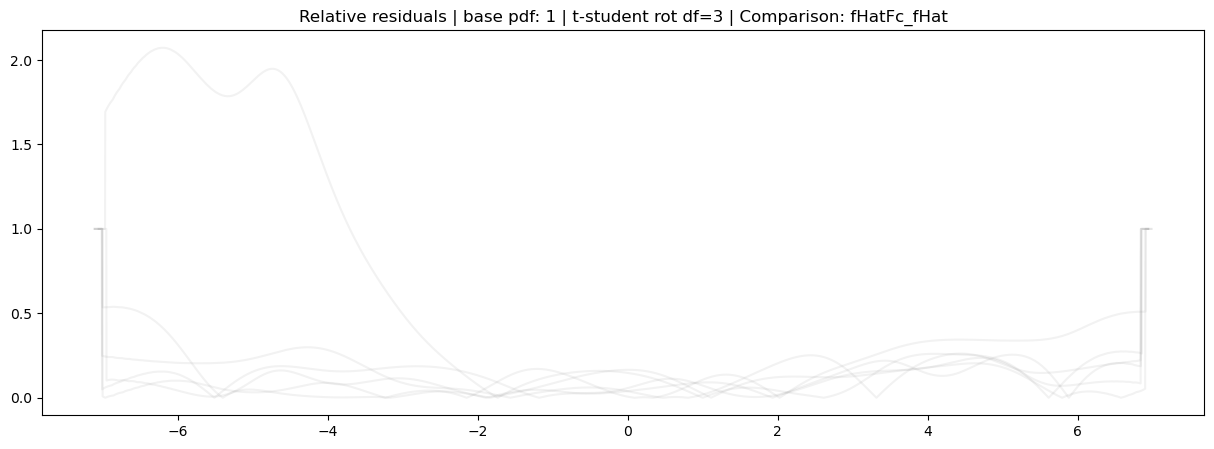

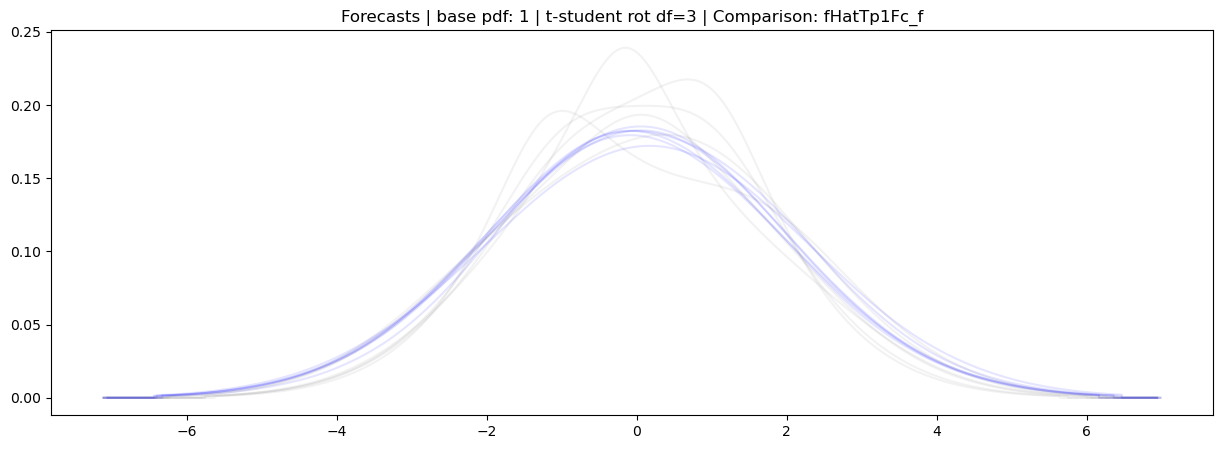

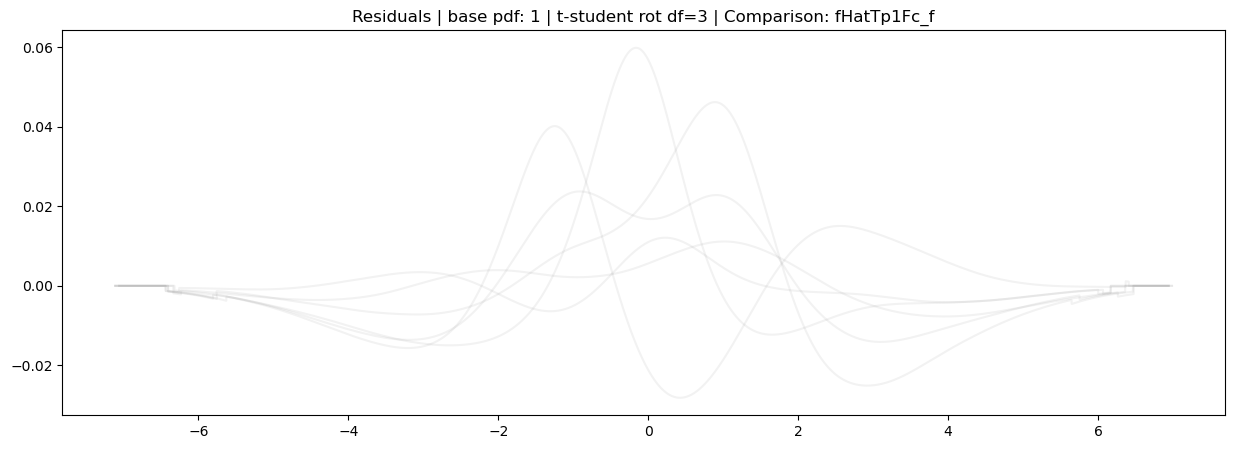

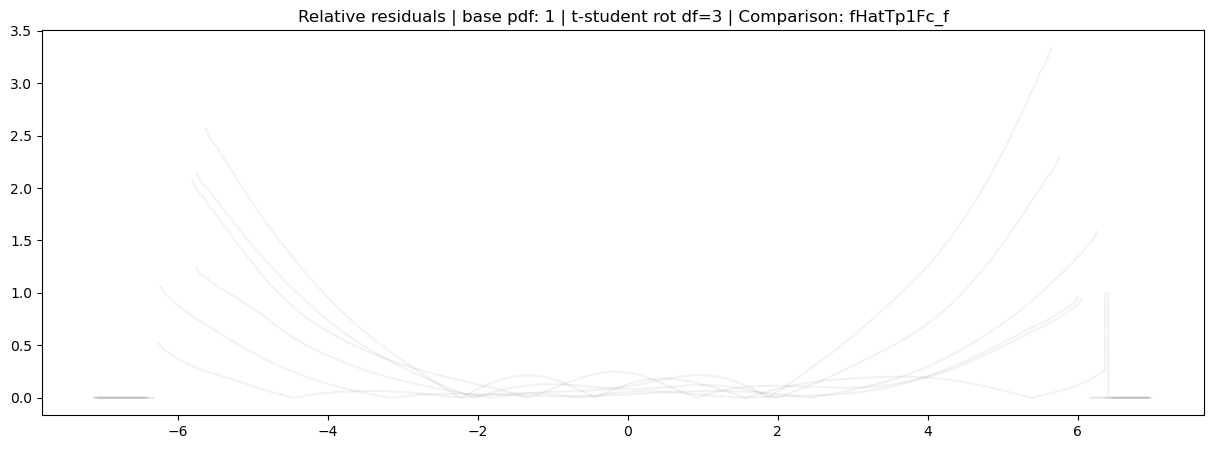

In [66]:
for scenario in df_cv_results.scenario.unique():
    df_cv_2 = df_cv_results[df_cv_results["scenario"]==scenario]
    for kde_model_name in df_cv_2.model_name.unique():
        df_cv_3 = df_cv_2[df_cv_2["model_name"]==kde_model_name]
        for target in df_cv_3.comparison.unique():
            df_cv_4 = df_cv_3[df_cv_3.comparison == target]

            plt.figure(figsize=(15,5))
            for n, x in df_cv_4.iterrows():
                curves = x["curves"].reset_index()[["support", "actual", "forecast"]].set_index("support")
                plt.plot(curves["actual"], color="gray", alpha=0.1)
                plt.plot(curves["forecast"], color="blue", alpha=0.1)
            plt.title(f"Forecasts | base pdf: {scenario} | {kde_model_name} | Comparison: {target}")
            plt.show()

            plt.figure(figsize=(15,5))
            for n, x in df_cv_4.iterrows():
                curves = x["curves"].reset_index()[["support", "actual", "forecast"]].set_index("support")
                curves["residuals"] = curves.actual - curves.forecast
                plt.plot(curves["residuals"], color="gray", alpha=0.1)
            plt.title(f"Residuals | base pdf: {scenario} | {kde_model_name} | Comparison: {target}")
            plt.show()

            plt.figure(figsize=(15,5))
            for n, x in df_cv_4.iterrows():
                curves = x["curves"].reset_index()[["support", "actual", "forecast"]].set_index("support")
                curves["residuals"] = curves.actual - curves.forecast
                curves["rel_resid"] = (np.abs(curves["residuals"])/curves.actual).fillna(0)
                plt.plot(curves["rel_resid"], color="gray", alpha=0.1)
            plt.title(f"Relative residuals | base pdf: {scenario} | {kde_model_name} | Comparison: {target}")
            plt.show()


            # plt.figure(figsize=(15,5))
            # for fc_date in df_cv_3.fc_date.unique():
            #     df_cv_5 = df_cv_4[df_cv_4["fc_date"] == fc_date].iloc[0,:]
            #     curves = df_cv_5["curves"].reset_index()
            #     curves = curves[["support", "actual", "forecast"]].set_index("support")
                
            #     plt.title(f"Forecasts | base pdf: {scenario} | {kde_model_name} | Comparison: {target}")
            #     plt.plot(curves["actual"], color="gray", alpha=0.5)
            #     plt.plot(curves["forecast"], color="blue", alpha=0.5)
            # plt.show()
        
            # plt.figure(figsize=(15,5))
            # for fc_date in df_cv_4.fc_date.unique():
            #     df_cv_5 = df_cv_4[df_cv_4["fc_date"] == fc_date].iloc[0,:]
            #     curves = df_cv_5["curves"].reset_index()
            #     curves = curves[["support", "actual", "forecast"]].set_index("support")
            #     curves["residuals"] = curves.actual - curves.forecast
            #     curves["rel_resid"] = (np.abs(curves["residuals"])/curves.actual).fillna(0)
                
            #     plt.title(f"Relative residuals | base pdf: {scenario} | {kde_model_name} | Comparison: {target}")
            #     plt.plot(curves["rel_resid"], color="gray", alpha=0.5)
            # plt.show()